# 05 — Prefix Caching
**Builds on notebooks 01 → 02 → 03 → 04**

---

### What is Prefix Caching?

When multiple requests share the same prompt prefix, recomputing the KV cache for that
prefix in every request is pure waste.  Prefix caching stores completed KV blocks in a
hash table keyed on the tokens they contain, and reuses them for new requests:

```
Request A: [system prompt ............] [What is France's capital?  ]
Request B: [system prompt ............] [Explain photosynthesis.    ]
            ↑── shared ──────────────↑
            KV blocks computed once, mapped into both sequences.
            Only the question suffix needs to be prefilled.
```

### vLLM Hash Chain

Each KV block is identified by a **chain hash** of its prefix:

```
                    Block 1                  Block 2                  Block 3
         [A gentle breeze stirred] [the leaves as children] [laughed in the distance]

hash[0] = hash((0,           tuple(tokens[0:16])))
hash[1] = hash((hash[0],     tuple(tokens[16:32])))
hash[2] = hash((hash[1],     tuple(tokens[32:48])))
```

`parent_hash` chains the blocks so that `hash[2]` is unique to the full
48-token prefix — not just "laughed in the distance".

### What's New vs Notebook 04

| Component | Notebook 04 | Notebook 05 |
|---|---|---|
| `BlockAllocator` | simple free-list | + `inc_ref()` for shared blocks |
| `PrefixCache` | — | hash→physical_ids, LRU eviction |
| `LayeredBlockTable` | always allocates fresh | `attach_cached_prefix()` reuses blocks |
| `SequenceGroup` | — | tracks `n_cached_tokens` |
| Engine | `ContinuousBatchingEngine` | `PrefixAwareEngine` with cache lookup |



---
## 1. Setup
*(Replicated verbatim from notebook 04)*

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install -q sentencepiece transformers

import torch, torch.nn as nn, torch.nn.functional as F
import math, time, os, gc, subprocess, ctypes
import numpy as np
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from collections import deque, OrderedDict
from enum import Enum, auto
import heapq

assert torch.cuda.is_available(), 'Need GPU'
device = 'cuda'
props  = torch.cuda.get_device_properties(0)
TOTAL_VRAM = props.total_memory
print(f'GPU  : {props.name}')
print(f'VRAM : {TOTAL_VRAM/1e9:.2f} GB')
torch.manual_seed(42)
torch.backends.cuda.matmul.allow_tf32 = True

GPU  : Tesla T4
VRAM : 15.64 GB


In [3]:
# ── LLaMA backbone (identical to notebooks 01-03) ────────────────────────────
from transformers import AutoTokenizer

@dataclass
class LLaMAConfig:
    vocab_size      : int   = 32000
    dim             : int   = 768
    n_layers        : int   = 12
    n_heads         : int   = 12
    n_kv_heads      : int   = 6
    max_seq_len     : int   = 512
    ffn_dim_mult    : float = 2.6875
    norm_eps        : float = 1e-5
    rope_theta      : float = 10000.0
    dropout         : float = 0.0
    grad_checkpoint : bool  = False
    batch_size      : int   = 16
    grad_accum_steps: int   = 4
    max_iters       : int   = 10000
    eval_interval   : int   = 500
    eval_iters      : int   = 50
    log_interval    : int   = 100
    learning_rate   : float = 3e-4
    weight_decay    : float = 0.1
    beta1           : float = 0.9
    beta2           : float = 0.95
    grad_clip       : float = 1.0
    warmup_iters    : int   = 200
    min_lr          : float = 3e-5
    @property
    def head_dim(self):
      return self.dim // self.n_heads
    @property
    def ffn_hidden_dim(self):
        return ((int(self.ffn_dim_mult * self.dim) + 255) // 256) * 256

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps; self.gamma = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return self.gamma * (x.float() * torch.rsqrt(x.float().pow(2).mean(-1, keepdim=True) + self.eps)).type_as(x)

def precompute_rope_freqs(head_dim, max_seq_len, theta=10000.0, device='cpu'):
    freqs = 1.0 / (theta ** (torch.arange(0, head_dim, 2, dtype=torch.float32, device=device) / head_dim))
    t = torch.arange(max_seq_len, dtype=torch.float32, device=device)
    freqs = torch.outer(t, freqs)
    return torch.cos(freqs).repeat_interleave(2, dim=-1), torch.sin(freqs).repeat_interleave(2, dim=-1)

def rotate_half(x):
    return torch.stack([-x[..., 1::2], x[..., 0::2]], dim=-1).flatten(-2)

def apply_rope(q, k, cos, sin):
    c, s = cos.unsqueeze(0).unsqueeze(0), sin.unsqueeze(0).unsqueeze(0)
    return (q*c + rotate_half(q)*s).type_as(q), (k*c + rotate_half(k)*s).type_as(k)

def repeat_kv(x, n_rep):
    if n_rep == 1: return x
    B, nkv, T, hd = x.shape
    return x[:,:,None,:,:].expand(B,nkv,n_rep,T,hd).reshape(B,nkv*n_rep,T,hd)

class SwiGLUFFN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        h = cfg.ffn_hidden_dim
        self.w1 = nn.Linear(cfg.dim, h, bias=False)
        self.w2 = nn.Linear(h, cfg.dim, bias=False)
        self.w3 = nn.Linear(cfg.dim, h, bias=False)
    def forward(self, x):
      return self.w2(F.silu(self.w3(x)) * self.w1(x))

class LLaMAAttentionSimple(nn.Module):
    def __init__(self, cfg, layer_idx):
        super().__init__()
        self.n_heads = cfg.n_heads; self.n_kv_heads = cfg.n_kv_heads
        self.head_dim = cfg.head_dim; self.layer_idx = layer_idx
        self.wq = nn.Linear(cfg.dim, cfg.n_heads * cfg.head_dim, bias=False)
        self.wk = nn.Linear(cfg.dim, cfg.n_kv_heads * cfg.head_dim, bias=False)
        self.wv = nn.Linear(cfg.dim, cfg.n_kv_heads * cfg.head_dim, bias=False)
        self.wo = nn.Linear(cfg.n_heads * cfg.head_dim, cfg.dim, bias=False)

class LLaMABlock(nn.Module):
    def __init__(self, cfg, layer_idx):
        super().__init__()
        self.attention_norm = RMSNorm(cfg.dim, cfg.norm_eps)
        self.attention = LLaMAAttentionSimple(cfg, layer_idx)
        self.ffn_norm = RMSNorm(cfg.dim, cfg.norm_eps)
        self.ffn = SwiGLUFFN(cfg)

class LLaMAModelWeightsOnly(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.token_emb = nn.Embedding(cfg.vocab_size, cfg.dim)
        self.layers = nn.ModuleList([LLaMABlock(cfg, i) for i in range(cfg.n_layers)])
        self.norm = RMSNorm(cfg.dim, cfg.norm_eps)
        self.lm_head = nn.Linear(cfg.dim, cfg.vocab_size, bias=False)
        self.token_emb.weight = self.lm_head.weight
    def num_parameters(self):
        return sum(p.numel() for p in self.parameters())

In [4]:
# ── Load checkpoint ───────────────────────────────────────────────────────────
CKPT = '/content/drive/MyDrive/PagedInfer/llama_ckpt.pt'

torch.cuda.empty_cache(); gc.collect()
free_before, total = torch.cuda.mem_get_info()

ckpt  = torch.load(CKPT, map_location='cpu', weights_only=True)
valid = {f for f in LLaMAConfig.__dataclass_fields__}
cfg   = LLaMAConfig(**{k:v for k,v in ckpt['config'].items() if k in valid})

cos_table, sin_table = precompute_rope_freqs(cfg.head_dim, cfg.max_seq_len, cfg.rope_theta, device)

model = LLaMAModelWeightsOnly(cfg)
model.load_state_dict(ckpt['model_state'], strict=False)
model = model.half().to(device).eval()
torch.cuda.synchronize()

free_after, _ = torch.cuda.mem_get_info()
model_vram = free_before - free_after
print(f'Model loaded: {model.num_parameters()/1e6:.1f}M params  {model_vram/1e6:.0f} MB')

# ── Tokenizer ─────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained('huggyllama/llama-7b')
tokenizer.pad_token = tokenizer.eos_token
print(f'Tokenizer: vocab={tokenizer.vocab_size}')

Model loaded: 109.5M params  254 MB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/594 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

Tokenizer: vocab=32000


In [5]:
# ── KV pool sizing + allocation (same as nowtebook 03) ────────────────────────
BLOCK_SIZE           = 16
ACTIVATION_RESERVE_GB = 1.5   # slightly more headroom for batched forward
SAFETY_MARGIN_GB     = 0.5

free_now, _ = torch.cuda.mem_get_info()
kv_budget   = max(int(free_now - (ACTIVATION_RESERVE_GB + SAFETY_MARGIN_GB)*1e9), 0)

bytes_per_physical_block = BLOCK_SIZE * cfg.n_kv_heads * cfg.head_dim * 2
N_LOGICAL_BLOCKS  = int(kv_budget // (2 * cfg.n_layers * bytes_per_physical_block))
N_PHYSICAL_BLOCKS = N_LOGICAL_BLOCKS * cfg.n_layers

POOL_SHAPE = (N_PHYSICAL_BLOCKS, BLOCK_SIZE, cfg.n_kv_heads, cfg.head_dim)
pool_k = torch.zeros(POOL_SHAPE, dtype=torch.float16, device=device)
pool_v = torch.zeros(POOL_SHAPE, dtype=torch.float16, device=device)

torch.cuda.synchronize()
print(f'KV pool  : {N_LOGICAL_BLOCKS} logical blocks  {N_PHYSICAL_BLOCKS} physical slots')
print(f'Pool size: {pool_k.numel()*2*2/1e6:.0f} MB  (K+V fp16)')
print(f'Max tokens cached: {N_LOGICAL_BLOCKS * BLOCK_SIZE:,}')

KV pool  : 45007 logical blocks  540084 physical slots
Pool size: 13273 MB  (K+V fp16)
Max tokens cached: 720,112


In [6]:
# ── CUDA kernels (extended from notebook 03 — adds kv_batch_write) ───────────
CUDA_SRC = r"""
#include <cuda_runtime.h>
#include <cuda_fp16.h>
#include <stdint.h>
#define PA_BLOCK_DIM 64

// ── Kernel 1: kv_init_blocks ─────────────────────────────────────────────────
// Zero-fill a list of physical blocks. Grid=(N,BS,H) Block=(HD,)
__global__ void kv_init_blocks(
    __half* __restrict__ pool_k, __half* __restrict__ pool_v,
    const int* __restrict__ block_ids,
    int block_size, int n_kv_heads, int head_dim
) {
    int blk_idx = blockIdx.x, slot = blockIdx.y, head = blockIdx.z;
    int dim = threadIdx.x;
    if (dim >= head_dim) return;
    int phys_id = block_ids[blk_idx];
    int64_t idx = (int64_t)phys_id * block_size * n_kv_heads * head_dim
                + (int64_t)slot   * n_kv_heads  * head_dim
                + (int64_t)head   * head_dim + dim;
    pool_k[idx] = __float2half(0.0f);
    pool_v[idx] = __float2half(0.0f);
}

// ── Kernel 2: kv_write ────────────────────────────────────────────────────────
// Single-seq scatter. Grid=(T,H) Block=(HD,)
__global__ void kv_write(
    __half* __restrict__ pool_k, __half* __restrict__ pool_v,
    const __half* __restrict__ k_in, const __half* __restrict__ v_in,
    const int* __restrict__ phys_blocks, const int* __restrict__ slots,
    int n_kv_heads, int head_dim, int block_size
) {
    int tok = blockIdx.x, head = blockIdx.y, dim = threadIdx.x;
    if (dim >= head_dim) return;
    int phys_id = phys_blocks[tok], slot = slots[tok];
    int64_t src = (int64_t)tok  * n_kv_heads * head_dim + (int64_t)head * head_dim + dim;
    int64_t dst = (int64_t)phys_id * block_size * n_kv_heads * head_dim
                + (int64_t)slot    * n_kv_heads  * head_dim
                + (int64_t)head    * head_dim + dim;
    pool_k[dst] = k_in[src];
    pool_v[dst] = v_in[src];
}

// ── Kernel 3: kv_read ─────────────────────────────────────────────────────────
// Single-seq gather. Grid=(T,H) Block=(HD,)
__global__ void kv_read(
    const __half* __restrict__ pool_k, const __half* __restrict__ pool_v,
    __half* __restrict__ k_out, __half* __restrict__ v_out,
    const int* __restrict__ phys_blocks, const int* __restrict__ slots,
    int n_kv_heads, int head_dim, int block_size
) {
    int tok = blockIdx.x, head = blockIdx.y, dim = threadIdx.x;
    if (dim >= head_dim) return;
    int phys_id = phys_blocks[tok], slot = slots[tok];
    int64_t src = (int64_t)phys_id * block_size * n_kv_heads * head_dim
                + (int64_t)slot    * n_kv_heads  * head_dim
                + (int64_t)head    * head_dim + dim;
    int64_t dst = (int64_t)tok  * n_kv_heads * head_dim + (int64_t)head * head_dim + dim;
    k_out[dst] = pool_k[src];
    v_out[dst] = pool_v[src];
}

// ── Kernel 4: kv_batch_write ─────────────────────────────────────────────────
//
// NEW for continuous batching:
// Write K/V for MULTIPLE sequences in a single kernel launch.
// Avoids launching one kernel per sequence per layer per step.
//
// Inputs:
//   k_in / v_in      : (TOTAL_TOKENS, N_KV_HEADS, HEAD_DIM)  concatenated across seqs
//   phys_blocks      : (TOTAL_TOKENS,)  int32  physical block per token
//   slots            : (TOTAL_TOKENS,)  int32  slot within block per token
//
// Grid: (TOTAL_TOKENS, N_KV_HEADS)   Block: (HEAD_DIM,)
// Identical addressing to kv_write — just with more tokens in one launch.
__global__ void kv_batch_write(
    __half* __restrict__ pool_k, __half* __restrict__ pool_v,
    const __half* __restrict__ k_in, const __half* __restrict__ v_in,
    const int* __restrict__ phys_blocks, const int* __restrict__ slots,
    int n_kv_heads, int head_dim, int block_size
) {
    int tok = blockIdx.x, head = blockIdx.y, dim = threadIdx.x;
    if (dim >= head_dim) return;
    int phys_id = phys_blocks[tok], slot = slots[tok];
    int64_t src = (int64_t)tok  * n_kv_heads * head_dim + (int64_t)head * head_dim + dim;
    int64_t dst = (int64_t)phys_id * block_size * n_kv_heads * head_dim
                + (int64_t)slot    * n_kv_heads  * head_dim
                + (int64_t)head    * head_dim + dim;
    pool_k[dst] = k_in[src];
    pool_v[dst] = v_in[src];
}

// ── Kernel 5: kv_copy_blocks ─────────────────────────────────────────────────
//
// Copy one physical block to another — used during COW (copy-on-write)
// and prefix sharing. Copies both K and V.
// Grid: (BLOCK_SIZE, N_KV_HEADS)   Block: (HEAD_DIM,)
__global__ void kv_copy_blocks(
    __half* __restrict__ pool_k, __half* __restrict__ pool_v,
    int src_block, int dst_block,
    int block_size, int n_kv_heads, int head_dim
) {
    int slot = blockIdx.x, head = blockIdx.y, dim = threadIdx.x;
    if (dim >= head_dim) return;
    int64_t src = (int64_t)src_block * block_size * n_kv_heads * head_dim
                + (int64_t)slot * n_kv_heads * head_dim
                + (int64_t)head * head_dim + dim;
    int64_t dst = (int64_t)dst_block * block_size * n_kv_heads * head_dim
                + (int64_t)slot * n_kv_heads * head_dim
                + (int64_t)head * head_dim + dim;
    pool_k[dst] = pool_k[src];
    pool_v[dst] = pool_v[src];
}

// ── Kernel 6: paged_attention_unified ────────────────────────────────────────
//
// Handles BOTH prefill (T_q > 1) and decode (T_q = 1) sequences in ONE launch.
// This is the "single kernel call" for the whole iteration:
//   - Prefill seqs and decode seqs run as separate rows of the same grid
//   - Causal mask applied when q_len > 1 (prefill), skipped for decode
//
// Inputs:
//   q          : (TOTAL_Q_TOKENS, n_heads, head_dim)  — all queries concatenated
//                prefill seqs contribute T tokens each; decode seqs contribute 1
//   pool_k/v   : paged KV pool (N_PHYS, BLOCK_SIZE, N_KV_HEADS, HEAD_DIM)
//   block_table: (N_SEQS, MAX_BLOCKS)  int32 — THIS layer's physical block ids
//   context_lens:(N_SEQS,)  int32 — total KV tokens per seq (after write)
//   q_lens     : (N_SEQS,)  int32 — number of query tokens per seq, tells the length, if the length of query tokens  is > 1 for a sequence --> Prefill
//   q_offsets  : (N_SEQS,)  int32 — offset of each seq's queries in q tensor, tells where each sequence starts.
//   attn_out   : (TOTAL_Q_TOKENS, n_heads, head_dim)  fp16
//
// Grid  : (TOTAL_Q_TOKENS, N_HEADS)
//   blockIdx.x = query token index (global, across all seqs)
//   blockIdx.y = attention head
// Block : (PA_BLOCK_DIM=64)
//
// Each CUDA block handles attention for one (query_token, head) pair.
// It identifies which sequence it belongs to via q_offsets, then
// attends to the KV tokens in that sequence's paged pool via block_table.
// Causal mask: query token at position q_pos can only see KV positions <= q_pos.
// ─────────────────────────────────────────────────────────────────────────────
__global__ void paged_attention_unified(
    const __half* __restrict__ q,
    const __half* __restrict__ pool_k,
    const __half* __restrict__ pool_v,
    const int*    __restrict__ block_table,
    const int*    __restrict__ context_lens,
    const int*    __restrict__ q_lens,
    const int*    __restrict__ q_offsets,
    __half*       __restrict__ attn_out,
    int n_seqs,
    int n_heads,
    int n_kv_heads,
    int head_dim,
    int block_size,
    int max_blocks_per_seq,
    int64_t pool_elements
) {
    int q_tok_global = blockIdx.x;   // global query token index across all seqs
    int head_idx     = blockIdx.y;
    int tid          = threadIdx.x;

    int n_rep   = n_heads / n_kv_heads;
    int kv_head = head_idx / n_rep;

    // ── Find which sequence this query token belongs to ───────────────────────
    // Binary search over q_offsets to find seq_idx
    int seq_idx = 0;
    for (int s = 0; s < n_seqs; s++) {
        int seq_end = q_offsets[s] + q_lens[s];
        if (q_tok_global < seq_end) { seq_idx = s; break; }
    }

    int q_pos_in_seq = q_tok_global - q_offsets[seq_idx];  // local query position
    int ctx_len      = context_lens[seq_idx];               // total KV tokens
    int q_len        = q_lens[seq_idx];                     // queries this seq

    // KV position this query can attend UP TO (causal mask):
    // For a prefill seq with q_len tokens starting at KV offset (ctx_len - q_len),
    // query q_pos_in_seq can attend to KV positions 0..(ctx_len-q_len+q_pos_in_seq)
    // For decode (q_len==1): q_pos_in_seq=0, attends to all ctx_len positions
    int kv_end = (ctx_len - q_len) + q_pos_in_seq + 1;  // inclusive upper bound

    __shared__ float smem[PA_BLOCK_DIM];

    // Load query element
    float q_val = 0.0f;
    if (tid < head_dim) {
        int64_t q_idx = (int64_t)q_tok_global * n_heads * head_dim
                      + (int64_t)head_idx * head_dim + tid;
        q_val = __half2float(q[q_idx]);
    }

    float m_i = -1e9f;
    float l_i = 0.0f;
    float acc = 0.0f;

    // Attend to KV positions 0..kv_end-1 (causal)
    for (int pos = 0; pos < kv_end; pos++) {
        int logical_block = pos / block_size;
        int slot          = pos % block_size;
        int phys_id       = block_table[seq_idx * max_blocks_per_seq + logical_block];

        int64_t kv_base = (int64_t)phys_id * block_size * n_kv_heads * head_dim
                        + (int64_t)slot    * n_kv_heads * head_dim
                        + (int64_t)kv_head * head_dim;

        int64_t k_idx = kv_base + (int64_t)tid;
        float k_val = (tid < head_dim && k_idx < pool_elements)
                      ? __half2float(pool_k[k_idx]) : 0.0f;
        float v_val = (tid < head_dim && k_idx < pool_elements)
                      ? __half2float(pool_v[k_idx]) : 0.0f;

        // Dot product: shared-memory reduction
        smem[tid] = q_val * k_val;
        __syncthreads();
        for (int stride = PA_BLOCK_DIM / 2; stride > 0; stride >>= 1) {
            if (tid < stride) smem[tid] += smem[tid + stride];
            __syncthreads();
        }
        float score = smem[0] / sqrtf((float)head_dim);
        __syncthreads();

        // Online softmax
        float m_new     = fmaxf(m_i, score);
        float exp_score = expf(score - m_new);
        float rescale   = expf(m_i - m_new);
        if (tid < head_dim) acc = acc * rescale + exp_score * v_val;
        l_i = l_i * rescale + exp_score;
        m_i = m_new;
    }

    if (tid < head_dim) {
        float out_val = (l_i > 0.0f) ? acc / l_i : 0.0f;
        int64_t out_idx = (int64_t)q_tok_global * n_heads * head_dim
                        + (int64_t)head_idx * head_dim + tid;
        attn_out[out_idx] = __float2half(out_val);
    }
}

extern "C" {

void launch_init_blocks(void* pk, void* pv, const int* ids,
                        int n, int bs, int h, int hd) {
    dim3 grid(n, bs, h); dim3 block(hd);
    kv_init_blocks<<<grid,block>>>((__half*)pk,(__half*)pv,ids,bs,h,hd);
}

void launch_write(void* pk, void* pv, const void* ki, const void* vi,
                  const int* pb, const int* sl, int T, int h, int hd, int bs) {
    dim3 grid(T,h); dim3 block(hd);
    kv_write<<<grid,block>>>((__half*)pk,(__half*)pv,(const __half*)ki,(const __half*)vi,pb,sl,h,hd,bs);
}

void launch_read(const void* pk, const void* pv, void* ko, void* vo,
                 const int* pb, const int* sl, int T, int h, int hd, int bs) {
    dim3 grid(T,h); dim3 block(hd);
    kv_read<<<grid,block>>>((const __half*)pk,(const __half*)pv,(__half*)ko,(__half*)vo,pb,sl,h,hd,bs);
}

// batch_write: same signature as write but processes TOTAL_TOKENS at once
void launch_batch_write(void* pk, void* pv, const void* ki, const void* vi,
                        const int* pb, const int* sl,
                        int total_tokens, int h, int hd, int bs) {
    dim3 grid(total_tokens, h); dim3 block(hd);
    kv_batch_write<<<grid,block>>>((__half*)pk,(__half*)pv,
                                    (const __half*)ki,(const __half*)vi,
                                    pb,sl,h,hd,bs);
}

void launch_copy_blocks(void* pk, void* pv,
                        int src_block, int dst_block,
                        int bs, int h, int hd) {
    dim3 grid(bs, h); dim3 block(hd);
    kv_copy_blocks<<<grid,block>>>((__half*)pk,(__half*)pv,src_block,dst_block,bs,h,hd);
}


// ── paged_attention_unified launcher ─────────────────────────────────────────
// q          : (TOTAL_Q_TOKENS, n_heads, head_dim)
// block_table: (N_SEQS, max_blocks)  THIS layer's physical ids
// ctx_lens   : (N_SEQS,)  total KV per seq
// q_lens     : (N_SEQS,)  query tokens per seq
// q_offsets  : (N_SEQS,)  start offset of each seq in q
// Grid=(TOTAL_Q_TOKENS, n_heads)  Block=(PA_BLOCK_DIM=64)
void launch_paged_attn_unified(
    const void* q,
    const void* pool_k, const void* pool_v,
    const int*  block_table,
    const int*  context_lens,
    const int*  q_lens,
    const int*  q_offsets,
    void*       attn_out,
    int total_q_tokens, int n_seqs,
    int n_heads, int n_kv_heads, int head_dim,
    int block_size, int max_blocks_per_seq,
    int64_t pool_elements
) {
    dim3 grid(total_q_tokens, n_heads);
    dim3 block(PA_BLOCK_DIM);
    paged_attention_unified<<<grid, block>>>(
        (const __half*)q,
        (const __half*)pool_k, (const __half*)pool_v,
        block_table, context_lens, q_lens, q_offsets,
        (__half*)attn_out,
        n_seqs, n_heads, n_kv_heads, head_dim,
        block_size, max_blocks_per_seq, pool_elements
    );
}

} // extern "C"

"""

CU_PATH = '/tmp/kv_cb_kernels.cu'
SO_PATH = '/tmp/kv_cb_ops.so'

# Delete stale .so cache — ensures new kernel always compiles fresh
for _p in [CU_PATH, SO_PATH]:
    if os.path.exists(_p): os.remove(_p)

with open(CU_PATH, 'w') as f: f.write(CUDA_SRC)
major, minor = torch.cuda.get_device_capability(0)
nvcc_cmd = ['nvcc', f'-arch=sm_{major}{minor}', '-O2', '--use_fast_math',
            '-shared', '-Xcompiler', '-fPIC', '-o', SO_PATH, CU_PATH]
result = subprocess.run(nvcc_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print(result.stderr); raise RuntimeError('nvcc failed')
lib = ctypes.CDLL(SO_PATH, mode=ctypes.RTLD_GLOBAL)

# argtypes
lib.launch_init_blocks.argtypes  = [ctypes.c_void_p]*2 + [ctypes.c_void_p] + [ctypes.c_int]*4
lib.launch_write.argtypes        = [ctypes.c_void_p]*4 + [ctypes.c_void_p]*2 + [ctypes.c_int]*4
lib.launch_read.argtypes         = [ctypes.c_void_p]*4 + [ctypes.c_void_p]*2 + [ctypes.c_int]*4
lib.launch_batch_write.argtypes  = [ctypes.c_void_p]*4 + [ctypes.c_void_p]*2 + [ctypes.c_int]*4
lib.launch_copy_blocks.argtypes  = [ctypes.c_void_p]*2 + [ctypes.c_int]*5
# paged_attention_unified:
# q, pool_k, pool_v, block_table, ctx_lens, q_lens, q_offsets, attn_out,
# total_q_tokens, n_seqs, n_heads, n_kv_heads, head_dim, bs, max_blks, pool_elements
lib.launch_paged_attn_unified.argtypes = (
    [ctypes.c_void_p]*3 +        # q, pool_k, pool_v
    [ctypes.c_void_p]*4 +        # block_table, ctx_lens, q_lens, q_offsets
    [ctypes.c_void_p]   +        # attn_out
    [ctypes.c_int]*7 +           # total_q_tokens, n_seqs, n_heads, n_kv_heads, head_dim, bs, max_blks
    [ctypes.c_int64]             # pool_elements
)
lib.launch_paged_attn_unified.restype = None
for fn in [lib.launch_init_blocks, lib.launch_write, lib.launch_read,
           lib.launch_batch_write, lib.launch_copy_blocks,
           lib.launch_paged_attn_unified]:
    fn.restype = None

def _ptr(t):  return ctypes.c_void_p(t.data_ptr())
def _ci(x):   return ctypes.c_int(int(x))   # ← renamed from _i

def init_blocks_cuda(block_ids):
    if not block_ids: return
    ids_t = torch.tensor(block_ids, dtype=torch.int32, device=device).contiguous()
    lib.launch_init_blocks(_ptr(pool_k), _ptr(pool_v), _ptr(ids_t),
                           _ci(len(block_ids)), _ci(pool_k.shape[1]),
                           _ci(pool_k.shape[2]), _ci(pool_k.shape[3]))

def write_kv_cuda(k_in, v_in, phys_blocks, slots):
    T = int(k_in.shape[0])
    if T == 0: return
    lib.launch_write(_ptr(pool_k), _ptr(pool_v),
                     _ptr(k_in.contiguous().half()), _ptr(v_in.contiguous().half()),
                     _ptr(phys_blocks.contiguous().int()), _ptr(slots.contiguous().int()),
                     _ci(T), _ci(pool_k.shape[2]), _ci(pool_k.shape[3]), _ci(pool_k.shape[1]))

def read_kv_cuda(phys_blocks, slots):
    T = int(phys_blocks.shape[0])
    NKV, HD = int(pool_k.shape[2]), int(pool_k.shape[3])
    ko = torch.empty((T, NKV, HD), dtype=torch.float16, device=device)
    vo = torch.empty_like(ko)
    if T == 0: return ko, vo
    lib.launch_read(_ptr(pool_k), _ptr(pool_v), _ptr(ko), _ptr(vo),
                    _ptr(phys_blocks.contiguous().int()), _ptr(slots.contiguous().int()),
                    _ci(T), _ci(NKV), _ci(HD), _ci(pool_k.shape[1]))
    return ko, vo

def batch_write_kv_cuda(k_in, v_in, phys_blocks, slots):
    T = int(k_in.shape[0])
    if T == 0: return
    lib.launch_batch_write(_ptr(pool_k), _ptr(pool_v),
                           _ptr(k_in.contiguous().half()), _ptr(v_in.contiguous().half()),
                           _ptr(phys_blocks.contiguous().int()), _ptr(slots.contiguous().int()),
                           _ci(T), _ci(pool_k.shape[2]), _ci(pool_k.shape[3]), _ci(pool_k.shape[1]))

def copy_block_cuda(src_block: int, dst_block: int):
    lib.launch_copy_blocks(_ptr(pool_k), _ptr(pool_v),
                           _ci(src_block), _ci(dst_block),
                           _ci(pool_k.shape[1]), _ci(pool_k.shape[2]), _ci(pool_k.shape[3]))

def paged_attn_unified_cuda(
    q           : torch.Tensor,   # (TOTAL_Q_TOKENS, n_heads, head_dim)  fp16
    block_table : torch.Tensor,   # (N_SEQS, max_blocks)  int32 — THIS layer
    context_lens: torch.Tensor,   # (N_SEQS,)  int32 — total KV per seq
    q_lens      : torch.Tensor,   # (N_SEQS,)  int32 — query tokens per seq
    q_offsets   : torch.Tensor,   # (N_SEQS,)  int32 — q start offset per seq
) -> torch.Tensor:                # (TOTAL_Q_TOKENS, n_heads, head_dim)  fp16
    """
    Unified paged attention for prefill+decode in one kernel launch.
    Handles causal masking automatically:
      - Prefill seqs (q_lens > 1): query at position p attends to KV 0..p
      - Decode seqs  (q_lens = 1): attends to all ctx_len KV tokens
    Both run in the same grid — no separate prefill/decode kernel calls.
    """
    total_q = int(q.shape[0])
    n_seqs  = int(block_table.shape[0])
    n_heads = int(q.shape[1])
    hd      = int(q.shape[2])
    max_blks = int(block_table.shape[1])
    pool_els = int(pool_k.numel())
    attn_out = torch.empty_like(q)
    lib.launch_paged_attn_unified(
        _ptr(q.contiguous().half()),
        _ptr(pool_k), _ptr(pool_v),
        _ptr(block_table.contiguous().int()),
        _ptr(context_lens.contiguous().int()),
        _ptr(q_lens.contiguous().int()),
        _ptr(q_offsets.contiguous().int()),
        _ptr(attn_out),
        _ci(total_q), _ci(n_seqs),
        _ci(n_heads), _ci(cfg.n_kv_heads),
        _ci(hd), _ci(int(pool_k.shape[1])), _ci(max_blks),
        ctypes.c_int64(pool_els)
    )
    return attn_out

def clear_blocks_cuda(block_ids): init_blocks_cuda(block_ids)


print(f'CUDA kernels compiled ({os.path.getsize(SO_PATH)//1024} KB)')
print('   launch_init_blocks  launch_write  launch_read')
print('   launch_batch_write  launch_copy_blocks ')

CUDA kernels compiled (1000 KB)
   launch_init_blocks  launch_write  launch_read
   launch_batch_write  launch_copy_blocks 


---
## 2. PrefixCache — Hash-Based Block Store

`PrefixCache` maps `block_hash → List[physical_block_id]` (one id per layer).
Blocks stay alive after their sequence finishes — they are only released to
the allocator when the cache runs out of space (LRU eviction).

`BlockAllocator` gains one new method: **`inc_ref(block_id)`**.  
When a cached block is reused by a new sequence, both the cache entry and the
new sequence hold a reference.  The physical block is freed only when **both**
refs drop to zero.


In [7]:
# ── BlockAllocator with reference counting ────────────────────────────────────

class BlockAllocator:
    """
    Free-list allocator with reference counting.

    ref_count[b] tracks how many owners hold block b:
      • 1 = owned by exactly one sequence (normal case)
      • 2 = shared between a live sequence AND the prefix cache
      • 0 = free, back in the free-list

    inc_ref(b) is called when a cached block is reused by a new sequence.
    free(ids) decrements each id's ref count and returns it to the free-list
    only when the count reaches 0.
    """
    def __init__(self, n_total):
        self.n_total = n_total
        self._free   = deque(range(n_total))
        self._rc     = [0] * n_total            # reference counts

    def allocate(self, n=1):
        if len(self._free) < n:
            raise RuntimeError(f'OOM: need {n} blocks, {len(self._free)} free')
        ids = [self._free.popleft() for _ in range(n)]
        for b in ids: self._rc[b] = 1
        return ids

    def inc_ref(self, block_id: int):
        """Pin a block — called when the prefix cache reuses it for a new seq."""
        self._rc[block_id] += 1

    def free(self, ids):
        for b in ids:
            self._rc[b] -= 1
            if self._rc[b] == 0:
                self._free.append(b)

    def can_allocate(self, n=1):
      return len(self._free) >= n

    @property
    def n_free(self):
      return len(self._free)
    @property
    def n_used(self):
      return self.n_total - self.n_free
    def utilization(self):
      return self.n_used / self.n_total
    def __repr__(self):
        return f'BlockAllocator(free={self.n_free}/{self.n_total}, util={self.utilization():.1%})'


# ── PrefixCache ───────────────────────────────────────────────────────────────

class PrefixCache:
    """
    vLLM-style hash-based KV block cache.

    Storage
    -------
    _cache : OrderedDict[block_hash → List[int]]
              ↑ LRU order (most-recently-used at the end)
              └── List has length n_layers:
                  _cache[h][layer_idx] = physical_block_id for that layer

    Hashing
    -------
    block_hash(parent_hash, block_tokens)
        = hash((parent_hash, tuple(block_tokens)))

    The chain of parent hashes means every block's hash encodes the
    full token sequence from position 0 up to and including that block.
    Two blocks are identical iff their entire preceding context is identical.

    Cache operations
    ----------------
    match(token_ids, block_size)
        Walk the hash chain.  For each matching block, bump ref counts and
        add to the returned list.  Stop at the first miss.
        Returns: (n_matched_blocks, cached_ids_per_layer)

    insert(block_hash, ids_per_layer)
        Store a completed block.  Evict LRU blocks if over capacity.

    insert_sequence_blocks(token_ids, block_table, block_size)
        Insert ALL complete blocks of a finished prefill into the cache.
        Called by the engine immediately after prefill completes.

    evict_to_free(n)
        Evict up to n LRU blocks to create free allocator slots.
        Only evicts blocks whose ref count is 1 (cache is the sole owner).
    """

    def __init__(self, allocator: BlockAllocator, max_blocks: int = 0):
        """
        allocator  : the shared BlockAllocator
        max_blocks : maximum cached logical blocks (0 = no hard limit)
        """
        self.allocator  = allocator
        self.max_blocks = max_blocks
        self._cache : OrderedDict[int, List[int]] = OrderedDict()
        # Telemetry
        self.n_hits     = 0
        self.n_misses   = 0
        self.n_evicted  = 0

    # ── Hashing ──────────────────────────────────────────────────────────────

    @staticmethod
    def block_hash(parent_hash: int, block_tokens: tuple) -> int:
        """
        Compute the hash for one block.

        parent_hash   — hash of the immediately preceding block
                        (0 for the very first block in a sequence)
        block_tokens  — tuple of token IDs in this block

        Using a tuple as input ensures the hash is sensitive to the exact
        order of tokens, not just their presence.
        """
        return hash((parent_hash, block_tokens))

    def compute_hashes(self, token_ids: List[int], block_size: int) -> List[int]:
        """
        Compute the full hash chain for token_ids.

        Only COMPLETE blocks (length == block_size) are hashed.
        Partial trailing blocks are ignored because their KV is
        not fully written yet.

        Example (block_size=16, 48 tokens → 3 full blocks):
            h0 = hash((0,  tuple(tokens[0:16])))
            h1 = hash((h0, tuple(tokens[16:32])))
            h2 = hash((h1, tuple(tokens[32:48])))
        """
        n_complete = len(token_ids) // block_size
        hashes, parent = [], 0
        for i in range(n_complete):
            toks = tuple(token_ids[i * block_size : (i+1) * block_size])
            h    = self.block_hash(parent, toks)
            hashes.append(h)
            parent = h
        return hashes

    # ── Lookup ───────────────────────────────────────────────────────────────

    def match(
        self,
        token_ids  : List[int],
        block_size : int,
        n_layers   : int,
    ) -> Tuple[int, List[List[int]]]:
        """
        Find cached prefix blocks for a new request.

        Walk the hash chain and collect matching blocks until the first miss.
        Ref counts are bumped for every matched block so they cannot be evicted
        while the new sequence is using them.

        Returns
        -------
        n_matched   : int             — number of blocks reused from cache
        per_layer   : List[List[int]] — physical block ids
                      per_layer[layer][logical_block] = physical_block_id
        """
        if not self._cache:
            return 0, [[] for _ in range(n_layers)]

        hashes    = self.compute_hashes(token_ids, block_size)
        per_layer = [[] for _ in range(n_layers)]
        n_matched = 0

        for h in hashes:
            if h not in self._cache:
                self.n_misses += 1
                break
            ids = self._cache[h]   # List[int], length = n_layers
            for li, phys_id in enumerate(ids):
                per_layer[li].append(phys_id)
                self.allocator.inc_ref(phys_id)   # pin: cache + new seq share it
            self._cache.move_to_end(h)            # mark as recently used
            n_matched += 1
            self.n_hits += 1

        return n_matched, per_layer

    # ── Insertion ────────────────────────────────────────────────────────────

    def insert(self, block_hash: int, ids_per_layer: List[int]):
        """
        Cache one completed block.

        ids_per_layer : List[int] of length n_layers —
            ids_per_layer[li] = physical block id for layer li

        If the block hash is already present, just bump it to MRU.
        Evict LRU blocks if over capacity.
        """
        if block_hash in self._cache:
            self._cache.move_to_end(block_hash)
            return
        self._cache[block_hash] = ids_per_layer
        # Evict if over hard limit
        if self.max_blocks > 0:
            while len(self._cache) > self.max_blocks:
                self._evict_lru()

    def insert_sequence_blocks(
        self,
        token_ids   : List[int],
        block_table ,              # LayeredBlockTable or PrefixAwareBlockTable
        block_size  : int,
    ):
        """
        Insert ALL complete blocks of a just-prefilled sequence into the cache.

        Called by the engine right after prefill completes.
        Only fully written blocks are cached (n_complete = prompt_len // block_size).
        """
        hashes = self.compute_hashes(token_ids, block_size)
        for i, h in enumerate(hashes):
            if h not in self._cache:
                ids = [block_table.block_ids[li][i]
                       for li in range(block_table.n_layers)]
                self.insert(h, ids)

    # ── Eviction ─────────────────────────────────────────────────────────────

    def evict_to_free(self, n_logical_blocks: int) -> int:
        """
        Evict up to n_logical_blocks LRU blocks to free allocator space.

        A block is only evictable if its allocator ref count is exactly 1
        (the cache is the sole owner — no live sequence is using it).
        Returns how many were actually evicted.
        """
        evicted = 0
        while evicted < n_logical_blocks and self._cache:
            if self._evict_lru():
                evicted += 1
            else:
                break   # all remaining blocks have live refs — cannot evict
        return evicted

    def _evict_lru(self) -> bool:
        if not self._cache:
            return False
        lru_hash, ids = next(iter(self._cache.items()))
        # Only evict if the cache is the sole owner (ref_count == 1)
        if all(self.allocator._rc[bid] == 1 for bid in ids):
            del self._cache[lru_hash]
            self.allocator.free(ids)
            self.n_evicted += 1
            return True
        # Block is shared with a live seq — skip it (move to end, try next)
        self._cache.move_to_end(lru_hash)
        return False

    # ── Properties ───────────────────────────────────────────────────────────

    @property
    def n_cached(self):
      return len(self._cache)

    @property
    def hit_rate(self):
        t = self.n_hits + self.n_misses
        return self.n_hits / t if t > 0 else 0.0

    def __repr__(self):
        return (f'PrefixCache(cached={self.n_cached}, '
                f'hits={self.n_hits}, misses={self.n_misses}, '
                f'hit_rate={self.hit_rate:.1%}, evicted={self.n_evicted})')


---
## 3. PrefixAwareBlockTable

Extends `LayeredBlockTable` with one new method:

```python
attach_cached_prefix(cached_ids, n_tokens)
```

Instead of allocating fresh blocks for the matching prefix, this method
**maps** the cached physical block ids directly into `block_ids[layer]`.
The allocator ref counts were already bumped by `PrefixCache.match()`, so
the blocks are pinned.  `prefill_offset` in the engine is advanced to skip
those tokens — they don't need a forward pass.


In [8]:
class PrefixAwareBlockTable:
    """
    LayeredBlockTable that can reuse cached prefix blocks.

    For the cached portion (logical blocks 0..n_cached-1):
        - Physical block ids are inserted directly from the cache
        - No allocator.allocate() called for these blocks
        - Ref counts were bumped by PrefixCache.match()

    For the uncached suffix:
        - append_token / append_tokens work exactly as before

    Attribute n_cached_blocks tracks how many leading blocks came from
    the prefix cache (used for logging and metrics).
    """

    def __init__(self, seq_id, n_layers, block_size=BLOCK_SIZE):
        self.seq_id          = seq_id
        self.n_layers        = n_layers
        self.block_size      = block_size
        self.num_tokens      = 0
        self.block_ids       : List[List[int]] = [[] for _ in range(n_layers)]
        self.n_cached_blocks = 0   # how many leading blocks from prefix cache

    @property
    def num_blocks(self):
      return len(self.block_ids[0])

    @property
    def last_block_is_full(self):
        return self.num_tokens > 0 and (self.num_tokens % self.block_size) == 0

    @property
    def last_block_offset(self):
      return self.num_tokens % self.block_size

    def attach_cached_prefix(
        self,
        cached_ids : List[List[int]],   # [layer][logical_block] physical ids
        n_tokens   : int,               # tokens covered (= n_cached_blocks * block_size)
    ):
        """
        Map cached physical blocks into this block table without allocating.

        cached_ids[li][i] = physical block id for layer li, logical block i.
        Ref counts already bumped by PrefixCache.match() — nothing to do here.
        """
        n_blocks = len(cached_ids[0]) if cached_ids else 0
        for li in range(self.n_layers):
            self.block_ids[li] = list(cached_ids[li])
        self.num_tokens      = n_tokens
        self.n_cached_blocks = n_blocks

    def append_token(self, allocator, kv_cache=None):
        if self.num_blocks == 0 or self.last_block_is_full:
            new_ids = allocator.allocate(self.n_layers)
            for li in range(self.n_layers):
                self.block_ids[li].append(new_ids[li])
                if kv_cache is not None:
                    kv_cache.on_block_allocated(li, new_ids[li])
        self.num_tokens += 1

    def append_tokens(self, n, allocator, kv_cache=None):
        for _ in range(n):
          self.append_token(allocator, kv_cache)

    def translate(self, layer, pos):
        return self.block_ids[layer][pos // self.block_size], pos % self.block_size

    def get_all_physical_slots(self, layer):
        pbs, ss = [], []
        for pos in range(self.num_tokens):
            pb, s = self.translate(layer, pos)
            pbs.append(pb); ss.append(s)
        return pbs, ss

    def free(self, allocator, kv_cache=None):
        all_ids = [b for layer_ids in self.block_ids for b in layer_ids]
        if kv_cache is not None:
            kv_cache.on_blocks_freed(all_ids)
        allocator.free(all_ids)
        self.block_ids   = [[] for _ in range(self.n_layers)]
        self.num_tokens  = 0

    def blocks_needed_for(self, n_more_tokens):
        current_slots = self.num_blocks * self.block_size
        free_slots    = current_slots - self.num_tokens
        need_tokens   = max(0, n_more_tokens - free_slots)
        return math.ceil(need_tokens / self.block_size)

    def blocks_needed_next(self): return self.blocks_needed_for(1)

    def __repr__(self):
        return (f'PrefixAwareBlockTable(seq={self.seq_id}, '
                f'tokens={self.num_tokens}, blocks={self.num_blocks}, '
                f'cached_blocks={self.n_cached_blocks})')


class GPUPagedKVCache:
    def __init__(self, n_layers):
        self.n_layers = n_layers
    def on_block_allocated(self, layer, block_id):
        init_blocks_cuda([block_id])
    def on_blocks_freed(self, block_ids):
        clear_blocks_cuda(block_ids)
    def write_tokens(self, layer, block_table, k_seq, v_seq, start_pos=0):
        T = k_seq.shape[0]
        phys_list, slot_list = [], []
        for i in range(T):
            pb, s = block_table.translate(layer, start_pos + i)
            phys_list.append(pb);
            slot_list.append(s)
        write_kv_cuda(k_seq, v_seq,
                      torch.tensor(phys_list, dtype=torch.int32, device=device),
                      torch.tensor(slot_list, dtype=torch.int32, device=device))
    def read_sequence(self, layer, block_table):
        pbs, ss = block_table.get_all_physical_slots(layer)
        return read_kv_cuda(torch.tensor(pbs, dtype=torch.int32, device=device),
                            torch.tensor(ss,  dtype=torch.int32, device=device))


# ── Shared instances ──────────────────────────────────────────────────────────
global_allocator = BlockAllocator(N_PHYSICAL_BLOCKS)
global_kv_cache  = GPUPagedKVCache(cfg.n_layers)
# Cache max = half the logical pool (leaves room for live sequences)
CACHE_MAX_BLOCKS = N_LOGICAL_BLOCKS // 2
prefix_cache     = PrefixCache(global_allocator, max_blocks=CACHE_MAX_BLOCKS)


---
## 4. Request · SequenceGroup · Scheduler
*(Replicated from notebook 04 — `SequenceGroup.block_table` is now `PrefixAwareBlockTable`; added `n_cached_tokens` field)*

In [9]:
@dataclass
class Request:
    request_id     : int
    prompt         : str
    max_new_tokens : int   = 64
    temperature    : float = 0.8
    top_k          : int   = 50
    priority       : int   = 0        # lower = higher priority
    arrival_time   : float = field(default_factory=time.time)

    def __lt__(self, other):
      return self.priority < other.priority


class RequestQueue:
    """
    Priority queue of incoming requests.
    Requests are ordered by (priority, arrival_time) — FIFO within same priority.
    """
    def __init__(self):
        self._heap : List[Tuple] = []
        self._counter = 0

    def add(self, request: Request):
        # (priority, tie-break counter, request) — counter ensures FIFO within priority
        heapq.heappush(self._heap, (request.priority, self._counter, request))
        self._counter += 1

    def pop(self) -> Optional[Request]:
        if self._heap:
            return heapq.heappop(self._heap)[2]
        return None

    def peek_priority(self) -> Optional[int]:
        return self._heap[0][0] if self._heap else None

    def __len__(self):
      return len(self._heap)
    def __bool__(self):
      return bool(self._heap)


In [10]:
# ── Chunked prefill threshold ────────────────────────────────────────────────
# If a prompt has more tokens than this, split it into chunks of this size.
# Prevents one long prefill from stalling all decoding seqs for many iterations.
CHUNKED_PREFILL_THRESHOLD = 32   # tokens per prefill chunk


class SeqStatus(Enum):
    WAITING         = auto()   # in queue, not yet scheduled
    PREFILL         = auto()   # being prefilled (possibly chunked)
    DECODING        = auto()   # actively generating
    SWAPPED         = auto()   # preempted — KV saved to CPU
    DONE            = auto()   # finished (EOS or max_tokens)


class SequenceGroup:
    """
    Holds all runtime state for one request.

      - swap_out() copies actual pool_k/pool_v GPU tensors to CPU RAM
        so KV does NOT need to be recomputed on swap-in
      - swap_in()  writes those CPU tensors back to the GPU pool
      - prefill_offset tracks chunked prefill progress
    """

    _id_counter = 0

    def __init__(self, request: 'Request'):
        self.seq_id           = SequenceGroup._id_counter
        SequenceGroup._id_counter += 1
        self.request          = request
        self.token_ids        = tokenizer.encode(request.prompt, add_special_tokens=True)
        self.prompt_len       = len(self.token_ids)
        self.n_generated      = 0
        self.status           = SeqStatus.WAITING
        self.block_table      = PrefixAwareBlockTable(self.seq_id, cfg.n_layers)

        # Chunked prefill: how many prompt tokens have been processed so far
        self.prefill_offset   = 0

        # Prefix cache: tokens covered by a cache hit
        self.n_cached_tokens  = 0

        # CPU KV storage: dict { layer_idx → (k_cpu, v_cpu) }
        # Each tensor shape: (num_tokens_at_swap, n_kv_heads, head_dim)  float16 on CPU
        self.cpu_kv_cache     = None

        # Metrics
        self.arrival_time     = request.arrival_time
        self.prefill_time     = None
        self.first_token_time = None
        self.finish_time      = None

    # ── Properties ──────────────────────────────────────────────────────────
    @property
    def total_tokens(self):
      return len(self.token_ids)

    @property
    def max_new_tokens(self):
      return self.request.max_new_tokens

    @property
    def is_done(self):
      return self.status == SeqStatus.DONE

    @property
    def last_token(self):
      return self.token_ids[-1]

    @property
    def prefill_remaining(self):
        """Number of prompt tokens not yet prefilled."""
        return self.prompt_len - self.prefill_offset

    @property
    def prefill_complete(self):
        return self.prefill_offset >= self.prompt_len

    @property
    def ttft(self):
        if self.first_token_time and self.arrival_time:
            return (self.first_token_time - self.arrival_time) * 1000
        return None

    @property
    def e2e_latency(self):
        if self.finish_time and self.arrival_time:
            return (self.finish_time - self.arrival_time) * 1000
        return None

    def blocks_needed_next(self) -> int:
        return self.block_table.blocks_needed_for(1)

    # ── Swap-out: copy GPU KV tensors to CPU ─────────────────────────────────
    def swap_out(self, kv_cache: 'GPUPagedKVCache', allocator: 'BlockAllocator'):
        """
        Preemption: copy the sequence's K/V from the GPU pool to CPU RAM,
        then free the GPU blocks. On swap-in, the tensors are written back
        to the pool directly — NO recomputation needed.

        For each layer we call read_sequence() which runs the kv_read CUDA
        kernel, then we move the result to CPU with .cpu().

        CPU memory cost: n_layers × 2 × num_tokens × n_kv_heads × head_dim × 2 bytes
        """
        self.cpu_kv_cache = {}
        for layer_idx in range(cfg.n_layers):
            # kv_read kernel: gathers this sequence's K and V from the pool
            k_gpu, v_gpu = kv_cache.read_sequence(layer_idx, self.block_table)
            # Move to CPU RAM — non-blocking pin for faster transfer
            self.cpu_kv_cache[layer_idx] = (
                k_gpu.cpu().pin_memory(),   # (num_tokens, n_kv_heads, head_dim)  fp16
                v_gpu.cpu().pin_memory(),
            )
        torch.cuda.synchronize()   # ensure all reads finished before freeing

        # Free GPU blocks — pool is now available for other sequences
        self.block_table.free(allocator, kv_cache)
        self.status = SeqStatus.SWAPPED
        n_tok = self.block_table.num_tokens   # 0 after free — use saved length
        # Reconstruct block_table will happen at swap-in time

    # ── Swap-in: write CPU tensors back to GPU pool ──────────────────────────
    def swap_in(self, kv_cache: 'GPUPagedKVCache', allocator: 'BlockAllocator'):
        """
        Restore: allocate fresh GPU blocks, write the saved CPU K/V tensors
        back into the pool via the kv_write CUDA kernel.
        No forward pass needed — the KV is already computed.
        """
        if self.cpu_kv_cache is None:
            # Fallback: no CPU cache saved, must re-prefill
            self.block_table = PrefixAwareBlockTable(self.seq_id, cfg.n_layers)
            self.prefill_offset = 0
            self.status = SeqStatus.PREFILL
            return

        # How many tokens were saved?
        n_saved = self.cpu_kv_cache[0][0].shape[0]   # from layer 0

        # Allocate fresh GPU blocks for all saved tokens
        self.block_table = PrefixAwareBlockTable(self.seq_id, cfg.n_layers)
        self.block_table.append_tokens(n_saved, allocator, kv_cache)

        # Write each layer's K/V back to the GPU pool
        for layer_idx in range(cfg.n_layers):
            k_cpu, v_cpu = self.cpu_kv_cache[layer_idx]
            # Move back to GPU (non-blocking from pinned memory)
            k_gpu = k_cpu.to(device, non_blocking=True)
            v_gpu = v_cpu.to(device, non_blocking=True)
            torch.cuda.synchronize()
            # kv_write kernel: scatters K/V into the newly allocated blocks
            kv_cache.write_tokens(layer_idx, self.block_table, k_gpu, v_gpu, start_pos=0)

        self.cpu_kv_cache = None   # free CPU RAM
        self.status = SeqStatus.DECODING   # ready to continue decoding immediately

    def __repr__(self):
        chunk_info = f' chunk={self.prefill_offset}/{self.prompt_len}' if self.status == SeqStatus.PREFILL else ''
        return (f'Seq({self.seq_id} {self.status.name}{chunk_info} '
                f'toks={self.total_tokens} gen={self.n_generated})')


In [11]:
@dataclass
class SchedulerOutput:
    prefill_seqs  : List[SequenceGroup]   # run prefill (possibly chunked) this step
    decode_seqs   : List[SequenceGroup]   # run single-token decode this step
    preempted_seqs: List[SequenceGroup]   # evicted from GPU this step
    swapped_in    : List[SequenceGroup]   # restored from CPU this step


class Scheduler:
    """
    Iteration-level scheduler for continuous batching.

    Policy (updated):
      1. DECODE seqs get HIGHEST priority — they always run first and
         consume their block slots before any new seq is considered.
         Rationale: a decoding seq is close to finishing; starving it
         increases latency for no gain. New seqs can wait one iteration.

      2. Chunked prefill — if a prompt has more tokens than
         CHUNKED_PREFILL_THRESHOLD, only process one chunk this
         iteration. The seq stays in PREFILL status and resumes next
         iteration. This prevents one long prompt from blocking all
         decode seqs for many steps.

      3. Preemption — if pool exhausted evict the decoding seq with
         fewest generated tokens (cheapest to re-serve).
         swap_out() now saves KV to CPU so no recomputation on swap-in.
    """

    def __init__(
        self,
        allocator: BlockAllocator,
        max_batch_size  : int = 8,
        max_prefill_seqs: int = 4,
        chunk_size      : int = CHUNKED_PREFILL_THRESHOLD,
    ):
        self.allocator        = allocator
        self.max_batch_size   = max_batch_size
        self.max_prefill_seqs = max_prefill_seqs
        self.chunk_size       = chunk_size
        self.n_preemptions    = 0
        self.n_swaps_in       = 0
        self.n_chunks         = 0   # total chunked prefill steps

    def schedule(
        self,
        waiting  : List[SequenceGroup],
        running  : List[SequenceGroup],
        swapped  : List[SequenceGroup],
    ) -> SchedulerOutput:

        prefill_seqs    = []
        decode_seqs     = []
        preempted_seqs  = []
        swapped_in_seqs = []

        # ── PRIORITY 1: Reserve slots for ALL currently decoding seqs ─────────
        # Decode seqs are processed BEFORE any waiting seq is considered.
        # If a decode seq cannot get a block, we preempt ANOTHER decode seq
        # (never the incoming decode seq itself unless it's the only one left).
        still_running = []
        for seq in running:
            blocks_needed = seq.blocks_needed_next() * cfg.n_layers
            if blocks_needed == 0 or self.allocator.can_allocate(blocks_needed):
                still_running.append(seq)
                decode_seqs.append(seq)
            else:
                # Pool exhausted — must preempt before we can continue
                # Find the cheapest victim among already-confirmed running seqs
                if still_running:
                    victim = min(still_running, key=lambda s: s.n_generated)
                    still_running.remove(victim)
                    decode_seqs.remove(victim)
                    # swap_out frees GPU blocks — pool now has room
                    victim.swap_out(global_kv_cache, self.allocator)
                    preempted_seqs.append(victim)
                    self.n_preemptions += 1

                # After freeing victim, check again if current seq fits
                if blocks_needed == 0 or self.allocator.can_allocate(blocks_needed):
                    decode_seqs.append(seq)
                    still_running.append(seq)
                else:
                    # Still no room (victim had 0 blocks or pool too small) — swap seq too
                    seq.swap_out(global_kv_cache, self.allocator)
                    preempted_seqs.append(seq)
                    self.n_preemptions += 1

        # ── PRIORITY 2: Restore swapped seqs (they were already running) ──────
        # Swapped seqs get priority over new waiting seqs because they have
        # already computed partial KV (saved to CPU) and users are waiting.
        for seq in swapped:
            # Blocks needed = blocks for all saved tokens (will be written back)
            n_saved = seq.cpu_kv_cache[0][0].shape[0] if seq.cpu_kv_cache else seq.prompt_len
            blocks_for_restore = math.ceil(n_saved / BLOCK_SIZE) * cfg.n_layers
            total_running = len(decode_seqs) + len(prefill_seqs) + len(swapped_in_seqs)
            if (self.allocator.can_allocate(blocks_for_restore) and
                    total_running < self.max_batch_size):
                # swap_in writes CPU tensors back to GPU pool — no forward pass needed
                seq.swap_in(global_kv_cache, self.allocator)
                swapped_in_seqs.append(seq)
                # After swap_in, status is DECODING — add to decode list
                decode_seqs.append(seq)
                self.n_swaps_in += 1

        # ── PRIORITY 3: Admit new waiting seqs for prefill ────────────────────
        # Only use remaining batch slots AFTER decode seqs are satisfied.
        n_prefill = 0
        for seq in waiting:
            if n_prefill >= self.max_prefill_seqs:
                break
            total_running = len(decode_seqs) + len(prefill_seqs)
            if total_running >= self.max_batch_size:
                break

            # ── Chunked prefill ───────────────────────────────────────────────
            # Determine how many tokens to process this iteration.
            # If prompt is long, only process chunk_size tokens at a time.
            chunk_end   = min(seq.prefill_offset + self.chunk_size, seq.prompt_len)
            chunk_len   = chunk_end - seq.prefill_offset
            blocks_for_chunk = math.ceil(chunk_len / BLOCK_SIZE) * cfg.n_layers

            if self.allocator.can_allocate(blocks_for_chunk):
                seq.status = SeqStatus.PREFILL
                prefill_seqs.append(seq)
                n_prefill += 1

        return SchedulerOutput(
            prefill_seqs   = prefill_seqs,
            decode_seqs    = decode_seqs,
            preempted_seqs = preempted_seqs,
            swapped_in     = swapped_in_seqs,
        )

---
## 5. PagedLLaMAInfer
*(Replicated verbatim from notebook 04 — no changes needed)*

In [12]:
# ── PagedLLaMAInfer — vLLM-style batched decode ───────────────────────────────

class PagedLLaMAInfer(nn.Module):
    def __init__(self, weights_model, cfg):
        super().__init__()
        self.cfg = cfg
        self.token_emb = weights_model.token_emb
        self.layers    = weights_model.layers
        self.norm      = weights_model.norm
        self.lm_head   = weights_model.lm_head
        mask = torch.triu(
            torch.full((1,1,cfg.max_seq_len,cfg.max_seq_len), float('-inf')), diagonal=1
        ).to(device)
        self.register_buffer('causal_mask', mask)

    @torch.no_grad()
    def forward(self, idx, block_table, kv_cache, start_pos=0):
        x = self.token_emb(idx)
        for li, layer in enumerate(self.layers):
            x = x + self._attn_forward(layer.attention_norm(x), li, block_table, kv_cache, start_pos)
            x = x + layer.ffn(layer.ffn_norm(x))
        return self.lm_head(self.norm(x))


    def _attn_forward(self, x, layer_idx, block_table, kv_cache, start_pos):
        """Single-sequence attention. Used during prefill."""
        B, T, _ = x.shape
        attn = self.layers[layer_idx].attention
        q = attn.wq(x).view(B,T,cfg.n_heads,   cfg.head_dim).transpose(1,2)
        k = attn.wk(x).view(B,T,cfg.n_kv_heads,cfg.head_dim).transpose(1,2)
        v = attn.wv(x).view(B,T,cfg.n_kv_heads,cfg.head_dim).transpose(1,2)
        cos = cos_table[start_pos:start_pos+T].to(x.device)
        sin = sin_table[start_pos:start_pos+T].to(x.device)
        q, k = apply_rope(q, k, cos, sin)
        kv_cache.write_tokens(layer_idx, block_table,
                              k.squeeze(0).permute(1,0,2).contiguous(),
                              v.squeeze(0).permute(1,0,2).contiguous(),
                              start_pos=start_pos)
        k_all, v_all = kv_cache.read_sequence(layer_idx, block_table)
        T_total = k_all.shape[0]
        k_all = repeat_kv(k_all.permute(1,0,2).unsqueeze(0), cfg.n_heads // cfg.n_kv_heads)
        v_all = repeat_kv(v_all.permute(1,0,2).unsqueeze(0), cfg.n_heads // cfg.n_kv_heads)
        scores = torch.matmul(q, k_all.transpose(-2,-1)) / math.sqrt(cfg.head_dim)
        if T > 1:
            scores = scores + self.causal_mask[:,:,start_pos:start_pos+T,:T_total].to(scores.device)
        weights = F.softmax(scores.float(), dim=-1).type_as(q)
        out = torch.matmul(weights, v_all).transpose(1,2).contiguous().view(B,T,-1)
        return attn.wo(out)

    @torch.no_grad()
    def forward_unified(
        self,
        prefill_seqs : List['SequenceGroup'],   # seqs being prefilled this iter
        decode_seqs  : List['SequenceGroup'],   # seqs doing 1-token decode
        kv_cache     : 'GPUPagedKVCache',
    ) -> Tuple[List[torch.Tensor], List[torch.Tensor]]:
        """
        Single kernel call for BOTH prefill and decode in the same iteration.

        Instead of:
          for each prefill_seq: forward(prompt)     ← N_p forward passes
          for each decode_seq:  forward_decode_batch ← 1 forward pass

        We do:
          1. Concatenate ALL query tokens (prefill T>1, decode T=1) into one tensor
          2. Run embedding + FFN once for all tokens together (N_p*T_p + N_d tokens)
          3. Write K/V for all tokens together (one batch_write kernel)
          4. ONE unified attention kernel: paged_attn_unified_cuda
             - prefill tokens attend causally to their own prefix
             - decode tokens attend to their full history
          5. Split output back into per-seq logit tensors

        Per layer: 4 + 1 + 1 = 6 launches regardless of N_p + N_d.
        Compare to separate: (N_p × 4) + (N_d × 4) launches.

        Returns:
          prefill_logits: List of (1, T, vocab) tensors — last position is first token
          decode_logits : List of (vocab,) tensors
        """
        all_seqs  = prefill_seqs + decode_seqs
        N         = len(all_seqs)
        if N == 0:
            return [], []

        # ── Build per-seq metadata ─────────────────────────────────────────────
        # q_lens[i]    = number of query tokens from seq i
        # q_offsets[i] = cumulative start index in the concatenated q tensor
        q_lens_list    = []
        q_offsets_list = []
        start_pos_list = []   # KV start position (= num_tokens before this call)
        offset = 0
        for seq in all_seqs:
            if seq in prefill_seqs:
                # Chunk: from prefill_offset to min(prefill_offset+chunk, prompt_len)
                chunk_start = seq.prefill_offset
                chunk_end   = min(chunk_start + CHUNKED_PREFILL_THRESHOLD, seq.prompt_len)
                t = chunk_end - chunk_start
            else:
                t = 1   # decode: always 1 new token
            q_lens_list.append(t)
            q_offsets_list.append(offset)
            start_pos_list.append(seq.block_table.num_tokens - t)
            offset += t

        total_q = offset   # total query tokens across all seqs

        # ── Collect all query token ids ───────────────────────────────────────
        all_toks = []
        for seq, t, sp in zip(all_seqs, q_lens_list, start_pos_list):
            if seq in prefill_seqs:
                chunk_start = seq.prefill_offset
                all_toks.extend(seq.token_ids[chunk_start : chunk_start + t])
            else:
                all_toks.append(seq.last_token)

        idx = torch.tensor(all_toks, dtype=torch.long, device=device)   # (total_q,)

        # ── Embedding — one call for all tokens ───────────────────────────────
        x = self.token_emb(idx)   # (total_q, dim)

        q_lens_t    = torch.tensor(q_lens_list,    dtype=torch.int32, device=device)
        q_offsets_t = torch.tensor(q_offsets_list, dtype=torch.int32, device=device)

        # ── Transformer layers ────────────────────────────────────────────────
        for li, layer in enumerate(self.layers):
            attn   = layer.attention
            x_norm = layer.attention_norm(x)   # (total_q, dim)

            # ── Batched Q/K/V — one matmul for all tokens ─────────────────────
            q_proj = attn.wq(x_norm).view(total_q, cfg.n_heads,    cfg.head_dim)
            k_proj = attn.wk(x_norm).view(total_q, cfg.n_kv_heads, cfg.head_dim)
            v_proj = attn.wv(x_norm).view(total_q, cfg.n_kv_heads, cfg.head_dim)

            # ── Batched RoPE ──────────────────────────────────────────────────────
            cos_b = torch.stack([
                cos_table[sp + lp]
                for sp, t in zip(start_pos_list, q_lens_list)
                for lp in range(t)
            ]).unsqueeze(1)   # (total_q, 1, head_dim) — broadcasts over n_heads
            sin_b = torch.stack([
                sin_table[sp + lp]
                for sp, t in zip(start_pos_list, q_lens_list)
                for lp in range(t)
            ]).unsqueeze(1)   # (total_q, 1, head_dim)

            # Direct RoPE
            q_r = (q_proj * cos_b + rotate_half(q_proj) * sin_b).to(torch.float16)
            k_r = (k_proj * cos_b + rotate_half(k_proj) * sin_b).to(torch.float16)
            # q_r: (total_q, n_heads,    head_dim)
            # k_r: (total_q, n_kv_heads, head_dim)

            # ── Build per-layer block_table + phys/slot lists ──────────────────
            # CRITICAL: use block_ids[li] — each layer has unique physical ids
            all_phys, all_slots = [], []
            bt_rows  = []
            max_blks = max(max(seq.block_table.num_blocks, 1) for seq in all_seqs)
            ctx_lens = []

            for si, seq in enumerate(all_seqs):
                t  = q_lens_list[si]
                sp = start_pos_list[si]
                for local_pos in range(t):
                    pb, slot = seq.block_table.translate(li, sp + local_pos)
                    all_phys.append(pb)
                    all_slots.append(slot)
                row = seq.block_table.block_ids[li]   # layer li ids
                bt_rows.append(row + [0] * (max_blks - len(row)))
                ctx_lens.append(seq.block_table.num_tokens)   # after append

            phys_t    = torch.tensor(all_phys,  dtype=torch.int32, device=device)
            slots_t   = torch.tensor(all_slots, dtype=torch.int32, device=device)
            bt_layer  = torch.tensor(bt_rows,   dtype=torch.int32, device=device)
            ctx_t     = torch.tensor(ctx_lens,  dtype=torch.int32, device=device)

            # ── Batch K/V write — all tokens, one kernel ──────────────────────
            batch_write_kv_cuda(k_r.contiguous(), v_proj.contiguous(), phys_t, slots_t)

            # ── Unified attention — ONE kernel for ALL seqs (prefill+decode) ──
            # Causal mask applied inside kernel: query i attends to KV 0..kv_end-1
            # where kv_end = (ctx_len - q_len) + q_pos_in_seq + 1
            attn_out = paged_attn_unified_cuda(
                q_r,          # (total_q, n_heads, head_dim)
                bt_layer,     # (N, max_blks)  — layer li physical ids
                ctx_t,        # (N,) — total KV per seq
                q_lens_t,     # (N,) — query tokens per seq
                q_offsets_t,  # (N,) — start offset per seq in q_r
            )   # → (total_q, n_heads, head_dim)

            # ── Output proj + residual + FFN ──────────────────────────────────
            attn_flat = attn_out.reshape(total_q, cfg.n_heads * cfg.head_dim)  # (total_q, dim)
            proj      = attn.wo(attn_flat)
            x = x + proj
            x = x + layer.ffn(layer.ffn_norm(x))

        # ── Output projection ─────────────────────────────────────────────────
        logits_all = self.lm_head(self.norm(x))   # (total_q, vocab)

        # ── Split back into per-seq results ───────────────────────────────────
        prefill_logits = []
        decode_logits  = []
        for si, seq in enumerate(all_seqs):
            off = q_offsets_list[si]
            t   = q_lens_list[si]
            seq_logits = logits_all[off : off + t]   # (t, vocab)
            if seq in prefill_seqs:
                prefill_logits.append(seq_logits)    # last row = first gen token
            else:
                decode_logits.append(seq_logits[0])  # (vocab,) for decode

        return prefill_logits, decode_logits


paged_llama = PagedLLaMAInfer(model, cfg)
paged_llama.eval()

def _sample(logits, temperature=0.8, top_k=50):
    logits = logits.float() / max(temperature, 1e-5)
    if top_k > 0:
        v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
        logits[logits < v[-1]] = float('-inf')
    return torch.multinomial(F.softmax(logits, dim=-1), 1).item()


---
## 6. PrefixAwareEngine

Extends `ContinuousBatchingEngine` with two prefix-cache hooks:

### `_try_prefix_match(seq)`
Called once per sequence at `prefill_offset == 0` (first chunk only).

```
prefix_cache.match(token_ids, BLOCK_SIZE, n_layers)
    → (n_cached_blocks, cached_ids_per_layer)

If n_cached_blocks > 0:
    seq.block_table.attach_cached_prefix(cached_ids, n_cached_blocks * BLOCK_SIZE)
    seq.prefill_offset = n_cached_blocks * BLOCK_SIZE   ← skip forward pass for cached tokens
    seq.n_cached_tokens = prefill_offset
```

### `_insert_into_cache(seq)`
Called once per sequence immediately after the last prefill chunk completes.

```
prefix_cache.insert_sequence_blocks(
    seq.token_ids[:seq.prompt_len],  ← only prompt tokens
    seq.block_table,
    BLOCK_SIZE
)
```

### Full prefill path comparison

```
Notebook 04                          Notebook 05
─────────────────────────────────    ──────────────────────────────────────────
allocate blocks for full prompt      1. check prefix cache
run forward on full prompt           2. attach cached blocks (no alloc, no fwd)
sample first token                   3. allocate blocks for suffix only
                                     4. run forward on suffix tokens only
                                     5. insert completed blocks into cache
                                     6. sample first token
```


In [13]:
@dataclass
class EngineMetrics:
    iteration          : int   = 0
    total_tokens_gen   : int   = 0
    total_requests_done: int   = 0
    n_preemptions      : int   = 0
    n_chunked_steps    : int   = 0
    n_swap_ins         : int   = 0
    start_time         : float = field(default_factory=time.time)
    ttft_list          : List[float] = field(default_factory=list)
    e2e_list           : List[float] = field(default_factory=list)
    iter_times         : List[float] = field(default_factory=list)
    queue_depths       : List[int]   = field(default_factory=list)
    gpu_util_samples   : List[float] = field(default_factory=list)

    @property
    def elapsed(self):
      return time.time() - self.start_time
    @property
    def throughput(self):
      return self.total_tokens_gen / max(self.elapsed, 1e-6)
    @property
    def avg_ttft(self):
      return float(np.mean(self.ttft_list)) if self.ttft_list else 0
    @property
    def avg_e2e(self):
      return float(np.mean(self.e2e_list))  if self.e2e_list  else 0


class PrefixAwareEngine:
    """
    Continuous batching engine — prefill + decode in ONE unified kernel call.

    Each iteration:
      1. Scheduler decides which seqs prefill / decode / preempt
      2. Block allocation for decode (append_token) and prefill (append_tokens)
      3. forward_unified() — one CUDA kernel call handles all seqs together
         • Prefill seqs: T > 1 query tokens, causal mask applied inside kernel
         • Decode  seqs: T = 1 query token,  attends to full history
      4. Sample tokens, update state, record metrics
    """

    def __init__(
        self,
        model          : 'PagedLLaMAInfer',
        allocator      : BlockAllocator,
        kv_cache       : 'GPUPagedKVCache',
        prefix_cache   : 'PrefixCache',
        max_batch_size : int = 8,
        max_prefill    : int = 4,
        log_every      : int = 5,
    ):
        self.model         = model
        self.allocator     = allocator
        self.kv_cache      = kv_cache
        self.prefix_cache  = prefix_cache
        self.scheduler     = Scheduler(allocator, max_batch_size, max_prefill)
        self.log_every     = log_every

        self.waiting_queue : List = []
        self.running       : List[SequenceGroup] = []
        self.swapped       : List[SequenceGroup] = []
        self.finished      : List[SequenceGroup] = []
        self.metrics       = EngineMetrics()

    def add_request(self, request: 'Request') -> int:
        seq = SequenceGroup(request)
        heapq.heappush(self.waiting_queue, (request.priority, seq.arrival_time, seq))
        return seq.seq_id

    def _pop_waiting(self) -> List[SequenceGroup]:
        return [item[2] for item in sorted(self.waiting_queue)]

    def _try_prefix_match(self, seq: SequenceGroup) -> int:
        """
        Check the prefix cache before allocating blocks for a new sequence.

        If matching blocks are found:
          - They are attached to seq.block_table (no allocator call)
          - seq.prefill_offset is advanced past the cached tokens
          - The engine will only run the forward pass on the suffix

        Returns the number of tokens covered by the cache hit.
        """
        n_matched, cached_ids = self.prefix_cache.match(
            seq.token_ids, BLOCK_SIZE, cfg.n_layers
        )
        if n_matched > 0:
            n_tok = n_matched * BLOCK_SIZE
            seq.block_table.attach_cached_prefix(cached_ids, n_tok)
            seq.prefill_offset  = n_tok
            seq.n_cached_tokens = n_tok
        return n_matched * BLOCK_SIZE

    def _insert_into_cache(self, seq: SequenceGroup):
        """
        Insert all complete prompt blocks into the prefix cache after prefill.

        Only complete blocks (n_tokens divisible by BLOCK_SIZE) are cached.
        The last partial block is excluded because its KV slot is not fully
        written yet — a future request extending this prefix by a few more
        tokens would get a hash mismatch anyway.
        """
        self.prefix_cache.insert_sequence_blocks(
            seq.token_ids[:seq.prompt_len],
            seq.block_table,
            BLOCK_SIZE
        )

    def _finish_seq(self, seq: SequenceGroup):
        seq.status      = SeqStatus.DONE
        seq.finish_time = time.time()
        seq.block_table.free(self.allocator, self.kv_cache)
        self.metrics.total_requests_done += 1
        self.finished.append(seq)
        if seq.ttft:
          self.metrics.ttft_list.append(seq.ttft)
        if seq.e2e_latency:
          self.metrics.e2e_list.append(seq.e2e_latency)

    def step(self) -> bool:
        t0 = time.time()
        self.metrics.iteration += 1

        waiting_seqs = self._pop_waiting()
        sched_out    = self.scheduler.schedule(
            waiting=waiting_seqs, running=self.running, swapped=self.swapped
        )

        # ── Preemptions — update tracking (swap already happened in scheduler) ──
        for seq in sched_out.preempted_seqs:
            if seq in self.running:
              self.running.remove(seq)
            if seq not in self.swapped:
              self.swapped.append(seq)

        # Remove admitted prefill seqs from waiting queue
        admitted_ids = {s.seq_id for s in sched_out.prefill_seqs}
        self.waiting_queue = [
            item for item in self.waiting_queue
            if item[2].seq_id not in admitted_ids
        ]

        # ── Allocate decode slots (with preemption guard) ─────────────────────
        active_decode = []
        for seq in sched_out.decode_seqs:
            if seq.is_done:
              continue
            blocks_needed = seq.blocks_needed_next() * cfg.n_layers
            if blocks_needed > 0 and not self.allocator.can_allocate(blocks_needed):
                candidates = [s for s in active_decode if not s.is_done]
                if candidates:
                    victim = min(candidates, key=lambda s: s.n_generated)
                    active_decode.remove(victim)
                    victim.swap_out(self.kv_cache, self.allocator)
                    self.swapped.append(victim)
                    if victim in self.running: self.running.remove(victim)
                    self.metrics.n_preemptions += 1
                else:
                    continue
            seq.block_table.append_token(self.allocator, self.kv_cache)
            active_decode.append(seq)

        # ── Allocate prefill blocks + capture chunk boundaries ────────────────
        # Capture (chunk_start, chunk_end, is_last) BEFORE forward_unified so
        # we can use these exact values when processing results.
        # (prefill_offset must not be advanced until after sampling.)
        active_prefill    = []
        prefill_chunks    = []   # (chunk_start, chunk_end, is_last) per prefill seq

        for seq in sched_out.prefill_seqs:
            if seq.prefill_time is None:
                seq.prefill_time = time.time()
            # ── Prefix cache lookup (first chunk only) ───────────────────
            if seq.prefill_offset == 0 and seq.n_cached_tokens == 0:
                self._try_prefix_match(seq)
            chunk_start      = seq.prefill_offset
            chunk_end        = min(chunk_start + CHUNKED_PREFILL_THRESHOLD, seq.prompt_len)
            chunk_len        = chunk_end - chunk_start
            # ── Fully cached: entire prompt was in the cache ──────────────────
            # No forward pass needed — run a single-token forward at the last
            # cached position to get logits for sampling the first new token.
            if chunk_len == 0:
                seq.prefill_offset   = seq.prompt_len
                last_pos             = seq.prompt_len - 1
                # Allocate the slot for the first token (same as decode path)
                seq.block_table.append_token(self.allocator, self.kv_cache)
                # Mark as decoding so forward_unified treats it as T=1
                seq.status            = SeqStatus.DECODING
                seq.first_token_time  = time.time()   # TTFT = now (no prefill cost)
                active_decode.append(seq)
                admitted_ids.discard(seq.seq_id)
                continue   # skip append_tokens and active_prefill

            is_last          = (chunk_end >= seq.prompt_len)
            blocks_for_chunk = math.ceil(chunk_len / BLOCK_SIZE) * cfg.n_layers

            if not self.allocator.can_allocate(blocks_for_chunk):
                # No room — defer to next iteration
                if not any(item[2].seq_id == seq.seq_id for item in self.waiting_queue):
                    heapq.heappush(self.waiting_queue,
                                   (seq.request.priority, seq.arrival_time, seq))
                seq.status = SeqStatus.WAITING
                continue

            seq.block_table.append_tokens(chunk_len, self.allocator, self.kv_cache)
            active_prefill.append(seq)
            prefill_chunks.append((chunk_start, chunk_end, is_last))

        # ── ONE unified forward pass: all prefill + all decode seqs ───────────
        if active_prefill or active_decode:
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                prefill_logits, decode_logits = self.model.forward_unified(
                    active_prefill, active_decode, self.kv_cache
                )

            # ── Process prefill results ───────────────────────────────────────
            for seq, logits, (c_start, c_end, is_last) in zip(
                    active_prefill, prefill_logits, prefill_chunks):

                # Advance offset using the values captured before the forward pass
                seq.prefill_offset = c_end

                if is_last:
                    # Last chunk → sample first generated token
                    next_tok = _sample(
                        logits[-1], seq.request.temperature, seq.request.top_k
                    )
                    seq.token_ids.append(next_tok)
                    seq.n_generated      += 1
                    seq.first_token_time  = time.time()   # TTFT recorded here
                    seq.status            = SeqStatus.DECODING
                    # ── Insert completed blocks into prefix cache ─────────
                    self._insert_into_cache(seq)
                    if (next_tok == tokenizer.eos_token_id or
                            seq.n_generated >= seq.max_new_tokens):
                        self._finish_seq(seq)
                    elif seq not in self.running:
                        self.running.append(seq)
                else:
                    # More chunks remain — stay in PREFILL
                    seq.status = SeqStatus.PREFILL
                    self.metrics.n_chunked_steps += 1
                    if not any(item[2].seq_id == seq.seq_id for item in self.waiting_queue):
                        heapq.heappush(self.waiting_queue,
                                       (seq.request.priority - 0.5, seq.arrival_time, seq))

            # ── Process decode results ────────────────────────────────────────
            for seq, logits in zip(active_decode, decode_logits):
                next_tok = _sample(logits, seq.request.temperature, seq.request.top_k)
                seq.token_ids.append(next_tok)
                seq.n_generated          += 1
                self.metrics.total_tokens_gen += 1
                if (next_tok == tokenizer.eos_token_id or
                        seq.n_generated >= seq.max_new_tokens):
                    self._finish_seq(seq)
                    if seq in self.running:
                      self.running.remove(seq)
                elif seq not in self.running:
                    self.running.append(seq)

        # ── Swap-in cleanup ───────────────────────────────────────────────────
        for seq in sched_out.swapped_in:
            if seq in self.swapped:
              self.swapped.remove(seq)
        self.metrics.n_swap_ins       = self.scheduler.n_swaps_in
        self.metrics.n_preemptions    = self.scheduler.n_preemptions
        self.metrics.n_chunked_steps  = self.scheduler.n_chunks

        # ── Metrics ───────────────────────────────────────────────────────────
        iter_ms = (time.time() - t0) * 1000
        self.metrics.iter_times.append(iter_ms)
        self.metrics.queue_depths.append(len(self.waiting_queue))
        self.metrics.gpu_util_samples.append(self.allocator.utilization())

        if self.metrics.iteration % self.log_every == 0:
            m = self.metrics
            print(f'[iter {m.iteration:4d}] '
                  f'run={len(self.running):2d} '
                  f'wait={len(self.waiting_queue):2d} '
                  f'swap={len(self.swapped):2d} '
                  f'done={m.total_requests_done:3d} '
                  f'pool={self.allocator.utilization():.1%} '
                  f'{iter_ms:.0f}ms '
                  f'{m.throughput:.1f}tok/s')

        return bool(self.running or self.waiting_queue or self.swapped)

    def run_until_done(self, max_iters: int = 500) -> Dict:
        print(f'Starting: {len(self.waiting_queue)} requests  '
              f'chunk_size={CHUNKED_PREFILL_THRESHOLD}')
        for _ in range(max_iters):
            if not self.step():
              break
        print(f'Done in {self.metrics.iteration} iterations')
        return self.get_results()

    def get_results(self) -> Dict:
        return {
            seq.seq_id: {
                'prompt'     : seq.request.prompt,
                'output'     : tokenizer.decode(seq.token_ids, skip_special_tokens=True),
                'n_generated': seq.n_generated,
                'ttft_ms'    : seq.ttft,
                'e2e_ms'     : seq.e2e_latency,
            }
            for seq in self.finished
        }

    def print_summary(self):
        m = self.metrics
        print('\n' + '='*60)
        print('Engine Summary')
        print('='*60)
        print(f'  Iterations           : {m.iteration}')
        print(f'  Requests done        : {m.total_requests_done}')
        print(f'  Tokens generated     : {m.total_tokens_gen}')
        print(f'  Throughput           : {m.throughput:.1f} tok/s')
        print(f'  Avg TTFT             : {m.avg_ttft:.1f} ms')
        print(f'  Avg E2E latency      : {m.avg_e2e:.1f} ms')
        print(f'  Preemptions          : {m.n_preemptions}')
        print(f'  Swap-ins (no recompute): {m.n_swap_ins}')
        print(f'  Chunked prefill steps: {m.n_chunked_steps}')
        print(f'  Avg iter time        : {np.mean(m.iter_times):.1f} ms')
        print(f'  Avg GPU pool util    : {np.mean(m.gpu_util_samples):.1%}')
        print(f'  Peak GPU pool util   : {max(m.gpu_util_samples):.1%}')
        if hasattr(self, 'prefix_cache'):
            pc = self.prefix_cache
            print(f'  Prefix cache hits    : {pc.n_hits}')
            print(f'  Prefix cache misses  : {pc.n_misses}')
            print(f'  Prefix hit rate      : {pc.hit_rate:.1%}')
            print(f'  Blocks evicted       : {pc.n_evicted}')
            print(f'  Blocks cached        : {pc.n_cached}')


---
## 7. Experiments

In [14]:
# ── Experiment 1: Shared system prompt — cache hit rate ──────────────────────
print('='*65)
print('EXPERIMENT 1: Shared System Prompt — Hit Rate & Throughput')
print('='*65)
print()

# 38-token system prompt → 2 full blocks of 16 tokens + 6 leftover
# All 6 requests share this prefix → blocks computed once, reused 5×
SHARED_PREFIX = (
    "Once upon a time, in a small village near a big forest, "
    "there lived a kind old woman who knew many magical stories. "
    "Every evening the children would gather around her and listen. "
)
# Verify token count
prefix_toks   = tokenizer.encode(SHARED_PREFIX)
n_prefix_blks = len(prefix_toks) // BLOCK_SIZE
print(f'Shared prefix : {len(prefix_toks)} tokens  →  {n_prefix_blks} full blocks cacheable')
print()

# ── Per-request question suffixes ─────────────────────────────────────────────
# Each request = SHARED_PREFIX + a different story continuation.
# The prefix blocks are computed once and reused for all subsequent requests.
QUESTIONS = [
    "One day she told them about a little dragon who",
    "She began the story of a tiny girl named Lily who",
    "Then she spoke of a brave puppy who wanted to",
    "Next she described a friendly giant who lived near",
    "She told them about a small boat that could",
    "Finally she whispered the tale of a lost kitten who",
]

SequenceGroup._id_counter = 0
alloc1  = BlockAllocator(N_PHYSICAL_BLOCKS)
kv1     = GPUPagedKVCache(cfg.n_layers)
cache1  = PrefixCache(alloc1, max_blocks=CACHE_MAX_BLOCKS)
engine1 = PrefixAwareEngine(
    paged_llama, alloc1, kv1, cache1,
    max_batch_size=4, max_prefill=2, log_every=20
)

for i, q in enumerate(QUESTIONS):
    prompt = SHARED_PREFIX + " " + q
    engine1.add_request(Request(request_id=i, prompt=prompt, max_new_tokens=30))

t0 = time.time()
engine1.run_until_done(max_iters=500)
elapsed = time.time() - t0

engine1.print_summary()
print()
print(f'Actual  : {cache1.n_hits} hits across {len(QUESTIONS)} requests')


EXPERIMENT 1: Shared System Prompt — Hit Rate & Throughput

Shared prefix : 40 tokens  →  2 full blocks cacheable

Starting: 6 requests  chunk_size=32
[iter   20] run= 4 wait= 2 swap= 0 done=  0 pool=0.0% 17ms 54.3tok/s
[iter   40] run= 2 wait= 0 swap= 0 done=  4 pool=0.0% 23ms 80.8tok/s
[iter   60] run= 2 wait= 0 swap= 0 done=  4 pool=0.0% 15ms 88.8tok/s
Done in 61 iterations

Engine Summary
  Iterations           : 61
  Requests done        : 6
  Tokens generated     : 174
  Throughput           : 88.9 tok/s
  Avg TTFT             : 1149.0 ms
  Avg E2E latency      : 1637.8 ms
  Preemptions          : 0
  Swap-ins (no recompute): 0
  Chunked prefill steps: 0
  Avg iter time        : 32.0 ms
  Avg GPU pool util    : 0.0%
  Peak GPU pool util   : 0.0%
  Prefix cache hits    : 8
  Prefix cache misses  : 4
  Prefix hit rate      : 66.7%
  Blocks evicted       : 0
  Blocks cached        : 8

Actual  : 8 hits across 6 requests


In [15]:
# ── Experiment 2: TTFT — cached vs cold ──────────────────────────────────────
print('='*65)
print('EXPERIMENT 2: TTFT — Cached Prefix vs Cold (No Cache)')
print('='*65)
print()
print('Same prompts run twice through the SAME PrefixCache.')
print('Pass 1 = cold (fills cache).  Pass 2 = warm (hits cache).')
print()

PROMPTS_EXP2 = [
    "Once upon a time in a kingdom far away, a wise wizard discovered",
    "The scientist peered through the telescope and suddenly realized",
    "In the year 2150, humanity had colonized three planets and was now",
    "The ancient manuscript described a ritual that could only be performed",
]

def run_pass(prompts, cache, alloc, label):
    SequenceGroup._id_counter = 0
    kv     = GPUPagedKVCache(cfg.n_layers)
    engine = PrefixAwareEngine(paged_llama, alloc, kv, cache,
                               max_batch_size=4, max_prefill=2, log_every=9999)
    for i, p in enumerate(prompts):
        engine.add_request(Request(request_id=i, prompt=p,
                                   max_new_tokens=20, arrival_time=time.time()))
    engine.run_until_done(max_iters=300)
    ttfts = [s.ttft for s in engine.finished if s.ttft]
    avg   = sum(ttfts) / len(ttfts) if ttfts else 0
    print(f'  {label:12s}: avg TTFT = {avg:6.1f} ms  '
          f'hits={cache.n_hits:3d}  throughput={engine.metrics.throughput:.1f} tok/s')
    return engine, avg

# Pass 1 — cold
cold_alloc = BlockAllocator(N_PHYSICAL_BLOCKS)
shared_cache = PrefixCache(cold_alloc, max_blocks=CACHE_MAX_BLOCKS)
engine_cold, ttft_cold = run_pass(PROMPTS_EXP2, shared_cache, cold_alloc, 'Cold (pass 1)')

# Pass 2 — warm (reuse same cache, new allocator + kv)
warm_alloc = BlockAllocator(N_PHYSICAL_BLOCKS)
engine_warm, ttft_warm = run_pass(PROMPTS_EXP2, shared_cache, warm_alloc, 'Warm (pass 2)')

print()
if ttft_cold > 0 and ttft_warm > 0:
    print(f'  TTFT speedup (cold → warm) : {ttft_cold / ttft_warm:.2f}×')
    saved_blocks = shared_cache.n_hits
    print(f'  Blocks saved by caching    : {saved_blocks}  '
          f'({saved_blocks * BLOCK_SIZE} tokens not recomputed in pass 2)')
print(f'  Final cache state          : {shared_cache}')


EXPERIMENT 2: TTFT — Cached Prefix vs Cold (No Cache)

Same prompts run twice through the SAME PrefixCache.
Pass 1 = cold (fills cache).  Pass 2 = warm (hits cache).

Starting: 4 requests  chunk_size=32
Done in 21 iterations
  Cold (pass 1): avg TTFT =   30.2 ms  hits=  0  throughput=176.4 tok/s
Starting: 4 requests  chunk_size=32
Done in 21 iterations
  Warm (pass 2): avg TTFT =   29.0 ms  hits=  2  throughput=163.9 tok/s

  TTFT speedup (cold → warm) : 1.04×
  Blocks saved by caching    : 2  (32 tokens not recomputed in pass 2)
  Final cache state          : PrefixCache(cached=2, hits=2, misses=1, hit_rate=66.7%, evicted=0)


In [16]:
# ── Experiment 3: LRU Eviction Under Memory Pressure ─────────────────────────
print('='*65)
print('EXPERIMENT 3: LRU Eviction Under Memory Pressure')
print('='*65)
print()

TINY_CACHE = 4   # 4 logical blocks capacity — will force evictions

# Prompts are ~20-24 tokens → 1 full cacheable block each (16 tokens)
ORIG_PROMPTS = [
    "Once upon a time a little dragon lived on a tall mountain and every morning he flew over",
    "There was a kind old farmer who had a small brown dog and every single day they walked",
    "A tiny fairy named Bella lived deep in the flower garden and she loved to help the bees",
    "Tom was a small brave boy who wanted to find the magic key hidden inside the old oak tree",
    "In a big green forest there lived a wise old owl who knew every animal and every secret",
    "Lucy the little rabbit loved to eat carrots and every morning she hopped to the big garden",
]

# Verify token counts — must be >= BLOCK_SIZE for caching to work
print(f"Prompt token counts (BLOCK_SIZE={BLOCK_SIZE}, need >=16 for caching):")
for p in ORIG_PROMPTS:
    enc = tokenizer.encode(p)
    n_blks = len(enc) // BLOCK_SIZE
    status = "OK" if n_blks >= 1 else "TOO SHORT"
    print(f"  {len(enc):3d} tok → {n_blks} block(s) [{status}] | {p[:50]}...")
print()

# ── Cache capacity analysis ───────────────────────────────────────────────────
print(f"Cache capacity : {TINY_CACHE} logical blocks")
print(f"Unique prompts : {len(ORIG_PROMPTS)} → each contributes 1 block")
print(f"After pass 1   : {min(len(ORIG_PROMPTS), TINY_CACHE)} blocks cached, ")
print(f"                 {max(0, len(ORIG_PROMPTS) - TINY_CACHE)} block(s) evicted by LRU")
print()

# ── Pass 1: Run all 6 unique prompts to completion ───────────────────────────
# Each finishes prefill → calls _insert_into_cache() → block stored.
# After 4 blocks, the 5th insertion evicts the LRU block, and so on.
print("--- Pass 1: 6 unique prompts (fills 4-block cache, forces 2 evictions) ---")
SequenceGroup._id_counter = 0
alloc3  = BlockAllocator(N_PHYSICAL_BLOCKS)
kv3     = GPUPagedKVCache(cfg.n_layers)
cache3  = PrefixCache(alloc3, max_blocks=TINY_CACHE)
engine3 = PrefixAwareEngine(
    paged_llama, alloc3, kv3, cache3,
    max_batch_size=4, max_prefill=2, log_every=999
)
for i, p in enumerate(ORIG_PROMPTS):
    engine3.add_request(Request(request_id=i, prompt=p, max_new_tokens=30))

engine3.run_until_done(max_iters=600)

print(f"  Cache after pass 1 : {cache3}")
print(f"  Blocks evicted     : {cache3.n_evicted}  ← LRU eviction triggered")
print(f"  Blocks still cached: {cache3.n_cached}  (the 4 most recently used)")
print()

# ── Pass 2: Duplicate prompts — some hit cache, some miss ─────────────────────
# Prompts 4 and 5 were the most recently inserted → should still be in cache.
# Prompts 0 and 1 were inserted first → evicted by LRU to make room.
# This gives a mix of hits (MRU survivors) and misses (evicted blocks).
print("--- Pass 2: Send all 6 prompts again (MRU blocks hit, evicted ones miss) ---")
SequenceGroup._id_counter = 6   # new seq ids
for i, p in enumerate(ORIG_PROMPTS):
    engine3.add_request(Request(request_id=6+i, prompt=p, max_new_tokens=30))

engine3.run_until_done(max_iters=600)

engine3.print_summary()
print()

total_requests = 12
expected_hits  = TINY_CACHE  # the 4 MRU blocks survived eviction
expected_misses_pass1 = len(ORIG_PROMPTS)  # cold cache
expected_misses_pass2 = len(ORIG_PROMPTS) - TINY_CACHE  # evicted blocks
print(f"Expected: {expected_hits} hits (pass 2 MRU survivors)")
print(f"Expected: {expected_misses_pass1 + expected_misses_pass2} misses ")
print(f"         ({expected_misses_pass1} from cold pass 1 + {expected_misses_pass2} evicted in pass 2)")
print()
print(f"Actual cache hits     : {cache3.n_hits}")
print(f"Actual cache misses   : {cache3.n_misses}")
print(f"Actual evictions      : {cache3.n_evicted}")
print(f"Final hit rate        : {cache3.hit_rate:.1%}")
print(f"Final cache           : {cache3}")


EXPERIMENT 3: LRU Eviction Under Memory Pressure

Prompt token counts (BLOCK_SIZE=16, need >=16 for caching):
   21 tok → 1 block(s) [OK] | Once upon a time a little dragon lived on a tall m...
   20 tok → 1 block(s) [OK] | There was a kind old farmer who had a small brown ...
   22 tok → 1 block(s) [OK] | A tiny fairy named Bella lived deep in the flower ...
   21 tok → 1 block(s) [OK] | Tom was a small brave boy who wanted to find the m...
   20 tok → 1 block(s) [OK] | In a big green forest there lived a wise old owl w...
   22 tok → 1 block(s) [OK] | Lucy the little rabbit loved to eat carrots and ev...

Cache capacity : 4 logical blocks
Unique prompts : 6 → each contributes 1 block
After pass 1   : 4 blocks cached, 
                 2 block(s) evicted by LRU

--- Pass 1: 6 unique prompts (fills 4-block cache, forces 2 evictions) ---
Starting: 6 requests  chunk_size=32
Done in 60 iterations
  Cache after pass 1 : PrefixCache(cached=4, hits=0, misses=4, hit_rate=0.0%, evicted=2)
  Bl

In [17]:
# ── Experiment 4: Poisson arrivals with prefix sharing ───────────────────────
print('='*65)
print('EXPERIMENT 4: Poisson Arrivals + Prefix Sharing')
print('='*65)
print()
import random
random.seed(7); np.random.seed(7)

ITERS_PER_SECOND = 20
N_REQUESTS       = 10

SHARED_BASE = (
    "Once upon a time there was a little rabbit who lived in a cozy burrow. "
    "Every day the rabbit went on a new adventure in the forest. "
)
ARRIVALS_PROMPTS = [
    SHARED_BASE + "One morning the rabbit found a big red apple and",     # shared → miss (cold)
    SHARED_BASE + "The next day the rabbit met a friendly fox who",        # shared → hit
    "Tom was a small boy who loved to play near the river",               # unique → miss
    SHARED_BASE + "Then the rabbit discovered a hidden path that led to",  # shared → hit
    "There was once a little dog named Max who could not find his ball",   # unique → miss
    SHARED_BASE + "Suddenly the rabbit saw a tiny bird with a broken wing", # shared → hit
    "Once there was a kind farmer who had three cows and a",              # unique → miss
    SHARED_BASE + "That evening the rabbit sat under a big oak tree and",  # shared → hit
    "A little girl named Lily went to the market with her mother to",     # unique → miss
    SHARED_BASE + "The rabbit smiled and ran home to tell everyone about", # shared → hit
]

inter_s      = np.random.exponential(1.0 / 2.0, N_REQUESTS)
arrival_s    = np.cumsum(inter_s)
arrival_iters = [int(t * ITERS_PER_SECOND) for t in arrival_s]
max_toks     = [random.randint(20, 45) for _ in range(N_REQUESTS)]
print(f'Arrival iters: {arrival_iters}')
shared_base_toks = tokenizer.encode(SHARED_BASE)
print(f'Shared base   : {len(shared_base_toks)} tokens → {len(shared_base_toks)//BLOCK_SIZE} cacheable blocks')
print()

SequenceGroup._id_counter = 0
alloc4  = BlockAllocator(N_PHYSICAL_BLOCKS)
kv4     = GPUPagedKVCache(cfg.n_layers)
cache4  = PrefixCache(alloc4, max_blocks=CACHE_MAX_BLOCKS)
engine4 = PrefixAwareEngine(
    paged_llama, alloc4, kv4, cache4,
    max_batch_size=5, max_prefill=3, log_every=10
)

max_iters = arrival_iters[-1] + 150
for iteration in range(max_iters):
    for ri, arr in enumerate(arrival_iters):
        if arr == iteration:
            p = ARRIVALS_PROMPTS[ri % len(ARRIVALS_PROMPTS)]
            engine4.add_request(Request(
                request_id=ri, prompt=p,
                max_new_tokens=max_toks[ri],
                arrival_time=time.time()
            ))
            print(f'  → iter {iteration:3d}: req {ri}  "{p[:55]}..."')
    if not engine4.step(): break

engine4.print_summary()
print()
print(f'Cache stats: {cache4}')
print(f'Requests sharing base prefix saved ~{cache4.n_hits * BLOCK_SIZE} token computations')


EXPERIMENT 4: Poisson Arrivals + Prefix Sharing

Arrival iters: [0, 15, 21, 34, 72, 80, 87, 88, 91, 98]
Shared base   : 36 tokens → 2 cacheable blocks

  → iter   0: req 0  "Once upon a time there was a little rabbit who lived in..."
[iter   10] run= 1 wait= 0 swap= 0 done=  0 pool=0.0% 18ms 22.2tok/s
  → iter  15: req 1  "Once upon a time there was a little rabbit who lived in..."
[iter   20] run= 2 wait= 0 swap= 0 done=  0 pool=0.0% 15ms 43.0tok/s
  → iter  21: req 2  "Tom was a small boy who loved to play near the river..."
[iter   30] run= 3 wait= 0 swap= 0 done=  0 pool=0.0% 15ms 74.7tok/s
  → iter  34: req 3  "Once upon a time there was a little rabbit who lived in..."
[iter   40] run= 2 wait= 0 swap= 0 done=  2 pool=0.0% 15ms 90.2tok/s
[iter   50] run= 2 wait= 0 swap= 0 done=  2 pool=0.0% 14ms 96.8tok/s
[iter   60] run= 1 wait= 0 swap= 0 done=  3 pool=0.0% 14ms 95.7tok/s
[iter   70] run= 1 wait= 0 swap= 0 done=  3 pool=0.0% 14ms 92.4tok/s
  → iter  72: req 4  "There was once a l

---
## 8. Metrics Dashboard

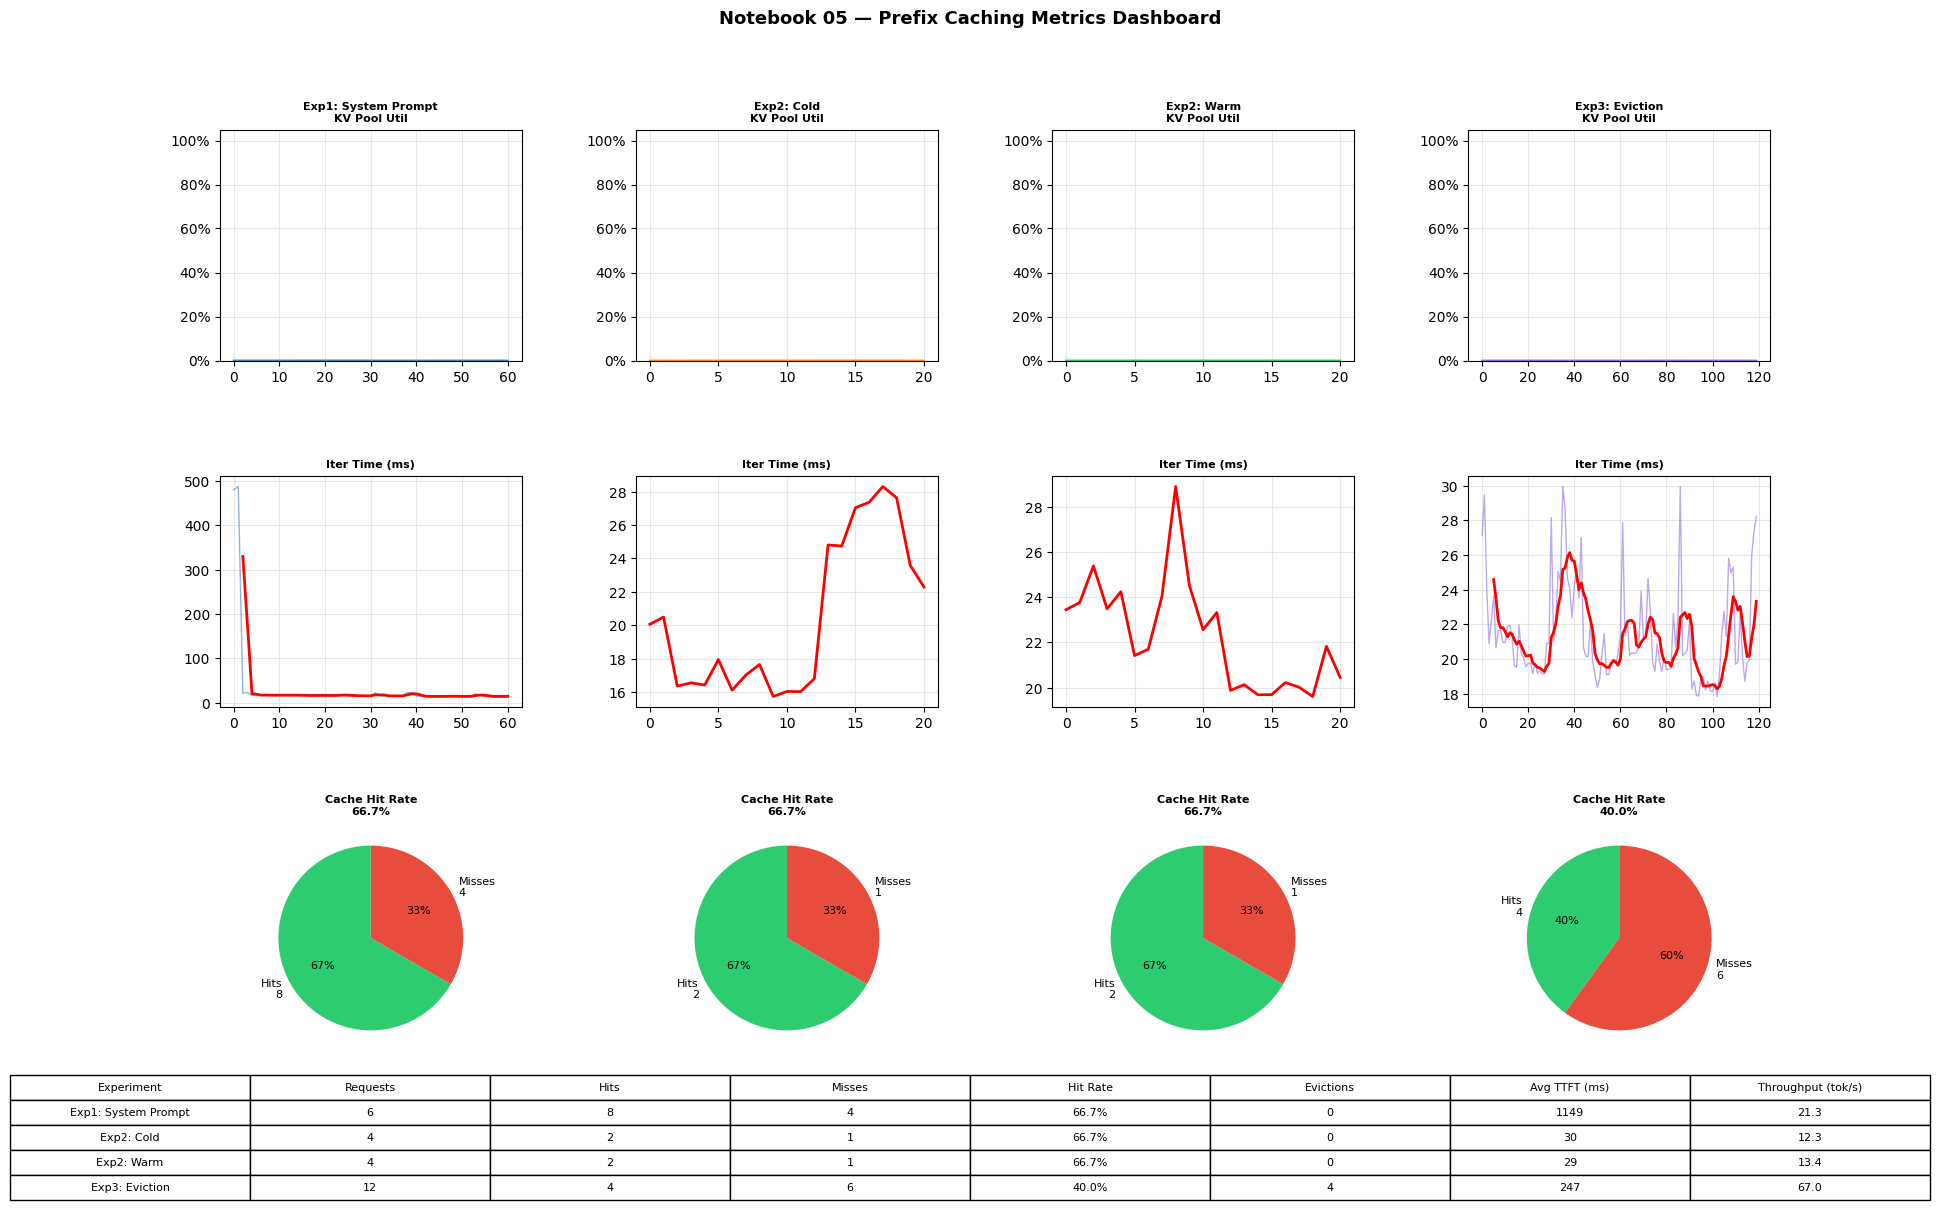

Saved: prefix_cache_dashboard.png


In [18]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    fig = plt.figure(figsize=(20, 12))
    gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.38)

    experiments = [
        ('Exp1: System Prompt', engine1,     cache1),
        ('Exp2: Cold',          engine_cold,  shared_cache),
        ('Exp2: Warm',          engine_warm,  shared_cache),
        ('Exp3: Eviction',      engine3,      cache3),
    ]
    colors = ['steelblue', 'darkorange', '#2ecc71', 'mediumpurple']

    def trim(s):
        f = next((i for i,v in enumerate(s) if v>0), 0)
        l = len(s) - next((i for i,v in enumerate(reversed(s)) if v>0), len(s))
        return s[max(0,f-1):min(len(s),l+2)] or s

    for col, (label, eng, cache) in enumerate(experiments):
        m = eng.metrics

        # Row 0: pool util
        ax = fig.add_subplot(gs[0, col])
        raw  = m.gpu_util_samples
        plot = trim(raw) if any(v>0 for v in raw) else raw
        ax.plot(plot, color=colors[col], lw=1.3)
        ax.fill_between(range(len(plot)), plot, alpha=0.2, color=colors[col])
        ax.set_ylim(0, 1.05)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_:f'{y:.0%}'))
        ax.set_title(f'{label}\nKV Pool Util', fontsize=8, fontweight='bold')
        ax.grid(True, alpha=0.3)

        # Row 1: iter time
        ax = fig.add_subplot(gs[1, col])
        ax.plot(m.iter_times, color=colors[col], lw=1.0, alpha=0.6)
        k = max(1, len(m.iter_times)//20)
        sm = np.convolve(m.iter_times, np.ones(k)/k, mode='valid')
        ax.plot(range(k-1, len(m.iter_times)), sm, color='red', lw=2)
        ax.set_title('Iter Time (ms)', fontsize=8, fontweight='bold')
        ax.grid(True, alpha=0.3)

        # Row 2: cache hit pie
        ax = fig.add_subplot(gs[2, col])
        hits, misses = cache.n_hits, cache.n_misses
        if hits + misses > 0:
            ax.pie([hits, misses],
                   labels=[f'Hits\n{hits}', f'Misses\n{misses}'],
                   colors=['#2ecc71', '#e74c3c'], autopct='%1.0f%%',
                   startangle=90, textprops={'fontsize': 8})
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(f'Cache Hit Rate\n{cache.hit_rate:.1%}', fontsize=8, fontweight='bold')

    # TTFT comparison bar (Exp2 cold vs warm)
    ax_ttft = fig.add_axes([0.02, 0.01, 0.96, 0.06])
    ax_ttft.axis('off')
    rows = [['Experiment', 'Requests', 'Hits', 'Misses', 'Hit Rate', 'Evictions', 'Avg TTFT (ms)', 'Throughput (tok/s)']]
    for label, eng, cache in experiments:
        ttfts = [s.ttft for s in eng.finished if s.ttft]
        avg_t = f'{sum(ttfts)/len(ttfts):.0f}' if ttfts else 'N/A'
        rows.append([label, eng.metrics.total_requests_done,
                     cache.n_hits, cache.n_misses,
                     f'{cache.hit_rate:.1%}', cache.n_evicted,
                     avg_t, f'{eng.metrics.throughput:.1f}'])
    t = ax_ttft.table(cellText=rows[1:], colLabels=rows[0], loc='center', cellLoc='center')
    t.auto_set_font_size(False); t.set_fontsize(8); t.scale(1, 1.5)

    plt.suptitle('Notebook 05 — Prefix Caching Metrics Dashboard',
                 fontsize=13, fontweight='bold')
    plt.savefig('prefix_cache_dashboard.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved: prefix_cache_dashboard.png')
except Exception as e:
    print(f'Dashboard error: {e}')
